<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/iportfolio/images/logos/kuleuven.png/@@images/image-800-e89431243530c6a800aa1186b9f6891b.png" width=auto height=200px align=left>
</div>

# KUL H02A5a Computer Vision — Group Assignment 1

**Team 27** | Fosteris Emmanouil · Paschalidis Marios · Greiner Luc · Reyes Salazar Jose · Digenis Stefanos

---

## Notebook structure

| Section | Content |
|---------|---------|
| 0 | Data loading & preprocessing |
| 1 | Feature representations (HOG, PCA) |
| 2 | Evaluation metrics |
| 3 | Classifiers |
| 4 | Experiments |
| 5 | Submitting best results |
| 6 | Discussion |

## File path setup (temporary)

In [74]:
import os
from pathlib import Path

target_folder = 'Assignment_1'
current_dir = Path.cwd()

# If we aren't already in the target folder, and it exists right here, move into it.
if current_dir.name != target_folder:
    if (current_dir / target_folder).is_dir():
        os.chdir(target_folder)
        print(f"✅ Moved down into: {Path.cwd()}")
    else:
        print(f"⚠️ '{target_folder}' not found. Staying in: {current_dir}")
else:
    print(f"ℹ️ Already in {target_folder}. No change needed.")

ℹ️ Already in Assignment_1. No change needed.


## Imports

In [75]:
# =============================================================================
# 1. Standard Library Imports
# =============================================================================
import os
import math
import threading
import random
import io
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib import request
import warnings

# =============================================================================
# 2. Data Processing & Visualization
# =============================================================================
import numpy as np
import pandas as pd
import cv2
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

# =============================================================================
# 3. Traditional Machine Learning (scikit-learn & skimage)
# =============================================================================
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate
)
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.base import clone

# Classifiers
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.gaussian_process import GaussianProcessClassifier
from xgboost import XGBClassifier

# Feature Extraction
from skimage.feature import hog

# =============================================================================
# 4. Deep Learning
# =============================================================================
import torch
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from facenet_pytorch import InceptionResnetV1

## Utility functions

The functions below are used to detect where the faces are in the pictures, preprocess them before using HOG, PCA or Neural Networks, to create charts or annotate the training data.

@TAs: There is no need to review in detail these functions. The more interesting pipelines are further down.

In [76]:
# Face detection:
"""
face_detection.py
-----------------
Face detection module for KUL H02A5a Computer Vision Group Assignment 1.

Provides two detectors:
    - HAARPreprocessor  : classical Haar cascade with 7-check filter pipeline
    - DNNFaceDetector   : ResNet SSD detector with sharpness-aware scoring

Typical usage
-------------
    from face_detection import DNNFaceDetector, HAARPreprocessor

    preprocessor = DNNFaceDetector(path='tmp', face_size=(100, 100))
    train_X = preprocessor(train)   # train is a DataFrame with an 'img' column
    test_X  = preprocessor(test)
"""


# =============================================================================
# Shared utilities
# =============================================================================


def _download_file(url: str, dest_path: str) -> None:
    """Downloads a file from *url* and writes it to *dest_path*."""
    print(f"  Downloading {os.path.basename(dest_path)} ...")
    with request.urlopen(url) as r, open(dest_path, "wb") as f:
        f.write(r.read())
    print(f"  Saved to {dest_path}")


def _nan_face(face_size: tuple) -> np.ndarray:
    """Returns an (H, W, 3) float32 array filled with NaN — used as a sentinel
    when no face is detected so downstream code can detect and skip it."""
    img = np.empty(face_size + (3,), dtype=np.float32)
    img[:] = np.nan
    return img


def _center_crop_fallback(img: np.ndarray, face_size: tuple) -> np.ndarray:
    """
    Last-resort fallback when detection finds nothing.

    Crops the largest centered square from *img* and resizes to *face_size*.
    Portrait photographers almost always center their subject, so a center
    crop is a reasonable guess and far better than returning NaN which gives
    the classifier nothing to work with.
    """
    h, w = img.shape[:2]
    size = min(h, w)
    y0 = (h - size) // 2
    x0 = (w - size) // 2
    crop = img[y0 : y0 + size, x0 : x0 + size]
    return cv2.resize(crop, face_size, interpolation=cv2.INTER_AREA).astype(np.float32)


# =============================================================================
# HAAR Preprocessor
# =============================================================================


class HAARPreprocessor:
    """
    Classical Haar cascade face detector with an extended false-positive
    filter pipeline and sharpness-aware face selection.

    Detection pipeline
    ------------------
    1. Haar cascade (strict params) → filter → keep survivors
    2. If nothing survives, relax params (scaleFactor=1.05, minNeighbors=3)
       and filter again.
    3. If still nothing, return center-crop fallback.

    Filter checks (ordered cheapest → most expensive)
    --------------------------------------------------
    1. Aspect ratio          0.7 – 1.4   (faces are roughly square)
    2. Minimum relative size ≥ 10 % of image width  (kills tiny BG faces)
    3. Vertical position     center in top 85 % of image
    4. Laplacian variance    ≥ 100       (rejects flat/uniform patches)
    5. Raw brightness        mean ≥ 50   (rejects genuinely dark regions)
    6. Skin tone             ≥ 15 % skin pixels in HSV space
    7. Colour variance       HSV-saturation std ≥ 20  (rejects plain walls/shirts)

    Face selection (when multiple candidates pass)
    -----------------------------------------------
    score = area × center_weight × eye_bonus × sharpness²

    Parameters
    ----------
    path         : directory to cache cascade XML files
    face_size    : output crop size as (width, height) tuple
    scale_factor : Haar scaleFactor (default 1.1)
    min_neighbors: Haar minNeighbors (default 5)
    n_jobs       : parallel workers (default = CPU count, max 8)
    """

    # Haar cascade URLs (OpenCV GitHub)
    _FACE_URL = (
        "https://raw.githubusercontent.com/opencv/opencv/master/data/"
        "haarcascades/haarcascade_frontalface_default.xml"
    )
    _EYE_URL = (
        "https://raw.githubusercontent.com/opencv/opencv/master/data/"
        "haarcascades/haarcascade_eye.xml"
    )

    def __init__(
        self,
        path: str,
        face_size: tuple,
        scale_factor: float = 1.1,
        min_neighbors: int = 5,
        n_jobs: int | None = None,
    ) -> None:
        self.face_size = face_size
        self.scale_factor = scale_factor
        self.min_neighbors = min_neighbors
        self.n_jobs = n_jobs or min(os.cpu_count() or 4, 8)

        os.makedirs(path, exist_ok=True)

        self._face_xml = os.path.join(path, "haarcascade_frontalface_default.xml")
        self._eye_xml = os.path.join(path, "haarcascade_eye.xml")

        if not os.path.exists(self._face_xml):
            _download_file(self._FACE_URL, self._face_xml)
        if not os.path.exists(self._eye_xml):
            _download_file(self._EYE_URL, self._eye_xml)

        # Thread-local storage for classifier instances.
        # CascadeClassifier is NOT thread-safe when shared — each thread
        # gets its own instance created on first use and reused thereafter.
        self._tls = threading.local()

    # ------------------------------------------------------------------
    # Thread-local classifier access
    # ------------------------------------------------------------------

    def _get_classifiers(self):
        if not hasattr(self._tls, "face_clf"):
            self._tls.face_clf = cv2.CascadeClassifier(self._face_xml)
            self._tls.eye_clf = cv2.CascadeClassifier(self._eye_xml)
        return self._tls.face_clf, self._tls.eye_clf

    # ------------------------------------------------------------------
    # Filter helpers
    # ------------------------------------------------------------------

    @staticmethod
    def _has_skin_tone(patch_rgb: np.ndarray) -> bool:
        """
        Returns True when ≥ 15 % of the patch pixels fall in the HSV
        skin-tone range.  Rejects cartoons, printed posters, and dark
        fabric that passed the brightness check due to fold edges.
        """
        hsv = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2HSV)
        lower = np.array([0, 30, 50], dtype=np.uint8)
        upper = np.array([25, 170, 255], dtype=np.uint8)
        mask = cv2.inRange(hsv, lower, upper)
        return mask.sum() / 255.0 / mask.size >= 0.15

    @staticmethod
    def _has_colour_variance(patch_rgb: np.ndarray) -> bool:
        """
        Returns True when the HSV saturation channel std ≥ 20.

        Real faces contain colour variation (lips, eyes, highlights,
        shadows).  Uniform surfaces — beige walls, plain shirts — pass
        the skin-tone hue check but have very low saturation variance.
        Threshold of 20 was chosen from empirical measurements:
        walls/shirts cluster below 15, real faces above 25.
        """
        hsv = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2HSV)
        return float(hsv[:, :, 1].std()) >= 20.0

    def _count_valid_eyes(self, crop_gray: np.ndarray, eye_clf) -> int:
        """
        Counts eyes in the TOP HALF of *crop_gray* and validates their
        vertical position.

        Searching only the top half prevents the detector locking on
        nostrils or mouth as false eyes.

        Brow ridges — the main false-positive for forehead crops — appear
        at < 15 % of crop height.  Real eyes sit between 20 % and 60 %.

        Returns 0, 1, or 2.
        """
        h = crop_gray.shape[0]
        top_half = crop_gray[: h // 2, :]
        eyes = eye_clf.detectMultiScale(
            top_half, scaleFactor=1.1, minNeighbors=4, minSize=(15, 15)
        )
        if len(eyes) == 0:
            return 0
        valid = [e for e in eyes if 0.20 <= (e[1] + e[3] / 2.0) / h <= 0.60]
        return len(valid)

    # ------------------------------------------------------------------
    # Main filter
    # ------------------------------------------------------------------

    def _filter(self, raw_faces, img, img_gray, img_h, img_w, eye_clf):
        """
        Applies all 7 checks to *raw_faces* and returns a list of
        (x, y, w, h, n_eyes, lap_var) tuples for surviving candidates.
        lap_var is stored here so _best_face can reuse it without
        recomputing the Laplacian.
        """
        survivors = []
        for x, y, w, h in raw_faces:
            # 1. Aspect ratio
            if not (0.7 <= w / float(h) <= 1.4):
                continue
            # 2. Minimum relative size
            if w / float(img_w) < 0.10:
                continue
            # 3. Vertical position of face centre
            if (y + h / 2) / float(img_h) > 0.85:
                continue

            patch_gray = img_gray[y : y + h, x : x + w]
            patch_raw = img[y : y + h, x : x + w]

            # 4. Texture variance (on equalized gray — good edge sensitivity)
            lap_var = cv2.Laplacian(patch_gray, cv2.CV_64F).var()
            if lap_var < 100:
                continue
            # 5. Brightness on RAW patch (equalized gray masks dark crops)
            if patch_raw.mean() < 50:
                continue
            # 6. Skin tone
            if not self._has_skin_tone(patch_raw):
                continue
            # 7. Colour variance
            if not self._has_colour_variance(patch_raw):
                continue

            n_eyes = self._count_valid_eyes(patch_gray, eye_clf)
            survivors.append((x, y, w, h, n_eyes, lap_var))

        return survivors

    # ------------------------------------------------------------------
    # Detection
    # ------------------------------------------------------------------

    def detect_faces(self, img: np.ndarray):
        """
        Two-stage detection with automatic fallback.

        Returns a list of (x, y, w, h, n_eyes, lap_var) tuples that
        passed all filter checks.  Empty list when nothing survives.
        """
        face_clf, eye_clf = self._get_classifiers()
        img_h, img_w = img.shape[:2]
        img_gray = cv2.equalizeHist(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))

        # Stage 1 — strict
        raw = face_clf.detectMultiScale(
            img_gray,
            scaleFactor=self.scale_factor,
            minNeighbors=self.min_neighbors,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE,
        )
        faces = self._filter(
            raw if len(raw) > 0 else [], img, img_gray, img_h, img_w, eye_clf
        )

        # Stage 2 — relaxed fallback
        if not faces:
            raw = face_clf.detectMultiScale(
                img_gray,
                scaleFactor=1.05,
                minNeighbors=3,
                minSize=(30, 30),
                flags=cv2.CASCADE_SCALE_IMAGE,
            )
            faces = self._filter(
                raw if len(raw) > 0 else [], img, img_gray, img_h, img_w, eye_clf
            )

        return faces

    # ------------------------------------------------------------------
    # Face selection
    # ------------------------------------------------------------------

    def _best_face(self, faces, img_h: int, img_w: int):
        """
        Returns the (x, y, w, h) of the highest-scoring candidate.

        Score = area × center_weight × eye_bonus × sharpness²

        area          : fraction of image covered → favours prominent faces
        center_weight : Gaussian decay from rule-of-thirds target (35 % from
                        top, horizontally centred) → portrait framing bias
        eye_bonus     : 2 eyes → 1.6×, 1 eye → 1.0×, 0 eyes → 0.4×
                        (soft penalty — not a hard gate)
        sharpness²    : (log(1+lap_var) / log(1+1000))²
                        Squared so in-focus foreground beats blurry background
                        even when area and position are similar.  Log compresses
                        the wide variance range (50 → 5000+).
        """
        img_area = float(img_h * img_w)
        cx_img = img_w / 2.0
        cy_target = img_h * 0.35  # rule of thirds
        sigma = 0.4 * np.sqrt(img_w**2 + img_h**2)
        sharp_norm = np.log1p(1000.0)
        eye_bonus = {0: 0.4, 1: 1.0, 2: 1.6}

        def _score(f):
            x, y, w, h, n_eyes, lap_var = f
            area = (w * h) / img_area
            dist_sq = (x + w / 2 - cx_img) ** 2 + (y + h / 2 - cy_target) ** 2
            cw = np.exp(-dist_sq / (2 * sigma**2))
            eb = eye_bonus.get(min(n_eyes, 2), 1.6)
            sharpness = (np.log1p(lap_var) / sharp_norm) ** 2
            return area * cw * eb * sharpness

        best = max(faces, key=_score)
        return best[:4]  # (x, y, w, h)

    # ------------------------------------------------------------------
    # Per-row preprocessing
    # ------------------------------------------------------------------

    def preprocess_single(self, data_row) -> np.ndarray:
        img = data_row["img"]
        faces = self.detect_faces(img)
        if not faces:
            return _center_crop_fallback(img, self.face_size)
        x, y, w, h = self._best_face(faces, img.shape[0], img.shape[1])
        return cv2.resize(
            img[y : y + h, x : x + w], self.face_size, interpolation=cv2.INTER_AREA
        ).astype(np.float32)

    def _process_row(self, args):
        idx, row = args
        return idx, self.preprocess_single(row)

    # ------------------------------------------------------------------
    # Public interface
    # ------------------------------------------------------------------

    def __call__(self, data, multi_face: bool = False) -> np.ndarray:
        """
        Parameters
        ----------
        data       : DataFrame with an 'img' column
        multi_face : reserved for future use (currently ignored)

        Returns
        -------
        np.ndarray of shape (N, H, W, 3) float32
        """
        rows = list(data.iterrows())
        results = [None] * len(rows)

        with ThreadPoolExecutor(max_workers=self.n_jobs) as pool:
            futures = {
                pool.submit(self._process_row, (i, row)): i
                for i, (_, row) in enumerate(rows)
            }
            for future in as_completed(futures):
                i, face = future.result()
                results[i] = face

        return np.stack(results).astype(np.float32)


# =============================================================================
# DNN Face Detector
# =============================================================================


class DNNFaceDetector:
    """
    OpenCV ResNet-SSD face detector with sharpness-aware candidate scoring.

    Why DNN over Haar
    -----------------
    The Haar pipeline required 7 hand-tuned filters to suppress false positives
    (shirts, walls, cartoons, background faces).  The DNN model learned to
    reject these internally during training, so almost no post-filtering is
    needed.  Confidence scores are also more semantically meaningful than
    Haar's minNeighbors heuristic.

    Scoring
    -------
    When multiple faces are detected, the best is chosen by:

        score = confidence² × area × center_weight × sharpness

    confidence²   : squared so high-confidence detections strongly dominate
    area          : fraction of image covered
    center_weight : Gaussian decay from rule-of-thirds target (35 % from top)
    sharpness     : log(1 + Laplacian_variance) / log(1 + 1000)
                    Key tiebreaker for group shots where conf and area are
                    similar — the in-focus foreground subject is always sharper.

    Parameters
    ----------
    path                 : directory to cache model files
    face_size            : output crop size as (width, height) tuple
    confidence_threshold : minimum DNN confidence to consider a detection
                           (default 0.5; raise to 0.7 to reduce false positives,
                           lower to 0.3 if valid faces are being missed)
    """

    _PROTO_URL = (
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/"
        "dnn/face_detector/deploy.prototxt"
    )
    _MODEL_URL = (
        "https://github.com/opencv/opencv_3rdparty/raw/"
        "dnn_samples_face_detector_20170830/"
        "res10_300x300_ssd_iter_140000.caffemodel"
    )

    def __init__(
        self,
        path: str,
        face_size: tuple,
        confidence_threshold: float = 0.5,
    ) -> None:
        self.face_size = face_size
        self.confidence_threshold = confidence_threshold

        os.makedirs(path, exist_ok=True)

        self._prototxt = os.path.join(path, "deploy.prototxt")
        self._caffemodel = os.path.join(
            path, "res10_300x300_ssd_iter_140000.caffemodel"
        )

        if not os.path.exists(self._prototxt):
            _download_file(self._PROTO_URL, self._prototxt)
        if not os.path.exists(self._caffemodel):
            _download_file(self._MODEL_URL, self._caffemodel)

        # Thread-local storage — cv2.dnn nets are not thread-safe when shared.
        self._tls = threading.local()

    # ------------------------------------------------------------------
    # Thread-local net access
    # ------------------------------------------------------------------

    def _get_net(self):
        if not hasattr(self._tls, "net"):
            self._tls.net = cv2.dnn.readNetFromCaffe(self._prototxt, self._caffemodel)
        return self._tls.net

    # ------------------------------------------------------------------
    # Sharpness
    # ------------------------------------------------------------------

    @staticmethod
    def _sharpness(img: np.ndarray, x: int, y: int, w: int, h: int) -> float:
        """
        Laplacian variance of the grayscale face patch, log-compressed.

        Uses the RAW (non-equalized) image so the score reflects true
        optical focus rather than artificially boosted contrast.
        log1p compresses the wide range (50 – 5000+) so extreme values
        don't dominate the composite score.
        """
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        patch = gray[y : y + h, x : x + w]
        lap_var = cv2.Laplacian(patch, cv2.CV_64F).var()
        return float(np.log1p(lap_var))

    # ------------------------------------------------------------------
    # Detection
    # ------------------------------------------------------------------

    def detect_faces(self, img: np.ndarray):
        """
        Runs the ResNet-SSD detector on *img* and returns all detections
        above *confidence_threshold* as a list of
        (x, y, w, h, confidence, sharpness) tuples sorted by confidence
        descending.
        """
        net = self._get_net()
        h, w = img.shape[:2]

        blob = cv2.dnn.blobFromImage(
            cv2.resize(cv2.cvtColor(img, cv2.COLOR_RGB2BGR), (300, 300)),
            1.0,
            (300, 300),
            (104.0, 177.0, 123.0),
        )
        net.setInput(blob)
        dets = net.forward()

        faces = []
        for i in range(dets.shape[2]):
            conf = float(dets[0, 0, i, 2])
            if conf < self.confidence_threshold:
                continue

            x1 = max(0, int(dets[0, 0, i, 3] * w))
            y1 = max(0, int(dets[0, 0, i, 4] * h))
            x2 = min(w, int(dets[0, 0, i, 5] * w))
            y2 = min(h, int(dets[0, 0, i, 6] * h))
            fw, fh = x2 - x1, y2 - y1

            if fw > 0 and fh > 0:
                sharp = self._sharpness(img, x1, y1, fw, fh)
                faces.append((x1, y1, fw, fh, conf, sharp))

        return sorted(faces, key=lambda f: f[4], reverse=True)

    # ------------------------------------------------------------------
    # Face selection
    # ------------------------------------------------------------------

    def _best_face(self, faces, img_h: int, img_w: int):
        """
        Returns the (x, y, w, h) of the highest-scoring candidate.

        Score = confidence² × area × center_weight × sharpness_weight
        """
        img_area = float(img_h * img_w)
        cx_img = img_w / 2.0
        cy_target = img_h * 0.35
        sigma = 0.4 * np.sqrt(img_w**2 + img_h**2)
        sharp_norm = np.log1p(1000.0)

        def _score(f):
            x, y, w, h, conf, sharp = f
            area = (w * h) / img_area
            dist_sq = (x + w / 2 - cx_img) ** 2 + (y + h / 2 - cy_target) ** 2
            cw = np.exp(-dist_sq / (2 * sigma**2))
            sw = sharp / sharp_norm
            return (conf**2) * area * cw * sw

        best = max(faces, key=_score)
        return best[:4]  # (x, y, w, h)

    # ------------------------------------------------------------------
    # Per-row preprocessing
    # ------------------------------------------------------------------

    def preprocess_single(self, data_row) -> np.ndarray:
        img = data_row["img"]
        faces = self.detect_faces(img)
        if not faces:
            return _center_crop_fallback(img, self.face_size)
        x, y, w, h = self._best_face(faces, img.shape[0], img.shape[1])
        return cv2.resize(
            img[y : y + h, x : x + w], self.face_size, interpolation=cv2.INTER_AREA
        ).astype(np.float32)

    def _process_row(self, args):
        idx, row = args
        return idx, self.preprocess_single(row)

    # ------------------------------------------------------------------
    # Public interface
    # ------------------------------------------------------------------

    def __call__(self, data) -> np.ndarray:
        """
        Parameters
        ----------
        data : DataFrame with an 'img' column

        Returns
        -------
        np.ndarray of shape (N, H, W, 3) float32
        """
        rows = list(data.iterrows())
        results = [None] * len(rows)
        n_jobs = min(os.cpu_count() or 4, 8)

        with ThreadPoolExecutor(max_workers=n_jobs) as pool:
            futures = {
                pool.submit(self._process_row, (i, row)): i
                for i, (_, row) in enumerate(rows)
            }
            for future in as_completed(futures):
                i, face = future.result()
                results[i] = face

        return np.stack(results).astype(np.float32)


# =============================================================================
# Convenience runner — called when the file is run directly
# =============================================================================


def run_preprocessing(
    train,
    test,
    detector: str = "dnn",
    face_size: tuple = (100, 100),
    model_path: str = "tmp",
    cache_path: str | None = None,
):
    """
    Runs the chosen detector on *train* and *test* DataFrames.

    Parameters
    ----------
    train      : training DataFrame with 'img' column
    test       : test DataFrame with 'img' column
    detector   : 'dnn' (recommended) or 'haar'
    face_size  : output crop dimensions (width, height)
    model_path : where to cache detector model files
    cache_path : if given, saves/loads preprocessed arrays from this directory
                 to skip reprocessing on subsequent runs

    Returns
    -------
    train_X : np.ndarray  (N_train, H, W, 3)
    train_y : np.ndarray  (N_train,)
    test_X  : np.ndarray  (N_test,  H, W, 3)
    """
    import shutil

    # --- Load from cache if available ---
    if cache_path and os.path.exists(cache_path):
        print(f"Loading cached arrays from '{cache_path}' ...")
        train_X = np.load(os.path.join(cache_path, "train_X.npy"))
        train_y = np.load(os.path.join(cache_path, "train_y.npy"))
        test_X = np.load(os.path.join(cache_path, "test_X.npy"))
        print(
            f"  train_X: {train_X.shape}  train_y: {train_y.shape}  test_X: {test_X.shape}"
        )
        return train_X, train_y, test_X

    # --- Choose detector ---
    if detector == "dnn":
        print("Using DNNFaceDetector ...")
        preprocessor = DNNFaceDetector(path=model_path, face_size=face_size)
    elif detector == "haar":
        print("Using HAARPreprocessor ...")
        preprocessor = HAARPreprocessor(path=model_path, face_size=face_size)
    else:
        raise ValueError(f"Unknown detector '{detector}'. Choose 'dnn' or 'haar'.")

    # --- Run preprocessing ---
    print("Preprocessing training set ...")
    train_X = preprocessor(train)
    train_y = train["class"].values

    print("Preprocessing test set ...")
    test_X = preprocessor(test)

    print(
        f"  train_X: {train_X.shape}  train_y: {train_y.shape}  test_X: {test_X.shape}"
    )

    # --- Optionally cache results ---
    if cache_path:
        if os.path.exists(cache_path):
            shutil.rmtree(cache_path)
        os.makedirs(cache_path)
        np.save(os.path.join(cache_path, "train_X.npy"), train_X)
        np.save(os.path.join(cache_path, "train_y.npy"), train_y)
        np.save(os.path.join(cache_path, "test_X.npy"), test_X)
        print(f"  Cached to '{cache_path}'")

    return train_X, train_y, test_X


In [77]:
# Preprocessing:
"""
preprocessing.py
----------------
Data transformation utilities for KUL H02A5a Computer Vision Group Assignment 1.

Transforms raw face crops (produced by face_detection.py) into feature vectors
ready for classifiers.

Functions
---------
    face_to_gray            : DNN/HAAR crop → uint8 grayscale, resized
    extract_hog_batch       : apply a HOGFeatureExtractor to a full array
    get_train_val_split     : stratified index-based split returning aligned arrays
    summarize_dataset       : prints a concise summary of the dataset

Pipeline summary
----------------
    Raw images
        │
        ▼  face_detection.py
    Face crops  (N, 150, 150, 3)  float32 RGB
        │
        ├──▶  extract_hog_batch  →  HOG features
        │
        └──▶  (Or passed directly to Deep Learning models in notebook)
"""


# =============================================================================
# 1. Image conversion
# =============================================================================


def face_to_gray(
    img_array: np.ndarray,
    target_size: tuple = (64, 64),
) -> np.ndarray:
    """
    Converts a single face crop to a uint8 grayscale image at *target_size*.

    Input is expected to be a float32 RGB array in [0, 255] as produced by
    DNNFaceDetector / HAARPreprocessor.  NaN crops (from failed detections)
    are silently converted to zero images so the pipeline never crashes —
    those samples simply get a zero feature vector downstream.

    Parameters
    ----------
    img_array   : face crop, shape (H, W, 3) float32, or NaN sentinel array
    target_size : (width, height) output size — (64, 64) is the standard
                  HOG input size and works well for PCA too

    Returns
    -------
    np.ndarray of shape (height, width), dtype uint8
    """
    if np.isnan(img_array).any():
        return np.zeros((target_size[1], target_size[0]), dtype=np.uint8)

    img_uint8 = np.clip(img_array, 0, 255).astype(np.uint8)

    if img_uint8.ndim == 3:
        img_gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img_uint8  # already grayscale

    return cv2.resize(img_gray, target_size, interpolation=cv2.INTER_AREA)


# =============================================================================
# 2. HOG feature extraction
# =============================================================================


def extract_hog_batch(
    gray_imgs: np.ndarray,
    extractor,
    verbose: bool = True,
) -> np.ndarray:
    """
    Applies *extractor*.transform() to every image in *gray_imgs*.

    Designed to work with HOGFeatureExtractor from the notebook, or any
    object that implements a .transform(img) → 1-D array interface.

    NaN/zero images (failed detections) produce a zero feature vector of
    the correct length so array shapes stay consistent.

    Parameters
    ----------
    gray_imgs : (N, H, W) uint8 grayscale array
    extractor : HOGFeatureExtractor instance (or compatible object)
    verbose   : print shape summary if True

    Returns
    -------
    np.ndarray of shape (N, feature_dim), float32
    """
    features = []
    ref_len = None  # determined from first successful extraction

    for img in gray_imgs:
        if img.max() == 0:
            # Blank image — append zero vector once we know the feature length
            if ref_len is not None:
                features.append(np.zeros(ref_len, dtype=np.float32))
            else:
                features.append(None)  # resolved in the second pass below
            continue

        feat = extractor.transform(img).astype(np.float32)
        ref_len = len(feat)
        features.append(feat)

    # Second pass: replace any None placeholders (blank images before first
    # valid image) now that we know ref_len
    if ref_len is None:
        raise ValueError(
            "extract_hog_batch: all images are blank — "
            "face detection may have failed for the entire set."
        )

    features = [
        f if f is not None else np.zeros(ref_len, dtype=np.float32) for f in features
    ]
    result = np.stack(features).astype(np.float32)

    if verbose:
        print("extract_hog_batch:")
        print(f"  Input  : {gray_imgs.shape}")
        print(f"  Output : {result.shape}  (feature vector length = {ref_len})")

    return result


# =============================================================================
# 3. Train / validation split
# =============================================================================


def get_train_val_split(
    *arrays,
    labels: np.ndarray,
    test_size: float = 0.25,
    random_state: int = 42,
    verbose: bool = True,
):
    """
    Stratified train/validation split that keeps multiple arrays aligned.

    Splitting by INDEX guarantees that features, gray images, face crops,
    and any other aligned arrays are split identically — avoids the subtle
    bug where calling train_test_split twice with the same random_state
    only works if the data is identical, which breaks silently after any
    preprocessing change.

    Parameters
    ----------
    *arrays      : any number of arrays to split, all must have the same N
                   e.g. get_train_val_split(hog_features, gray_imgs, labels=y)
    labels       : 1-D integer label array used for stratification
    test_size    : fraction of data for validation (default 0.25)
    random_state : fixed seed for reproducibility
    verbose      : print split summary if True

    Returns
    -------
    tuple of (train_array_1, val_array_1, train_array_2, val_array_2, ...)
    plus (train_labels, val_labels) appended at the end

    Example
    -------
    X_train, X_val, imgs_train, imgs_val, y_train, y_val = get_train_val_split(
        hog_features, gray_imgs, labels=train_y_dnn
    )
    """
    n = len(labels)
    for i, arr in enumerate(arrays):
        if len(arr) != n:
            raise ValueError(
                f"Array {i} has length {len(arr)} but labels has length {n}. "
                "All arrays must have the same number of samples."
            )

    indices = np.arange(n)
    train_idx, val_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=labels,
    )

    result = []
    for arr in arrays:
        result.append(arr[train_idx])
        result.append(arr[val_idx])

    # Append labels last
    result.append(labels[train_idx])
    result.append(labels[val_idx])

    if verbose:
        print("get_train_val_split:")
        print(f"  Total samples  : {n}")
        print(f"  Training       : {len(train_idx)}")
        print(f"  Validation     : {len(val_idx)}")
        print(
            f"  Train dist     : {dict(zip(*np.unique(labels[train_idx], return_counts=True)))}"
        )
        print(
            f"  Val   dist     : {dict(zip(*np.unique(labels[val_idx],   return_counts=True)))}"
        )

    return tuple(result)

# =============================================================================
# 4. Miscellaneous
# =============================================================================

def summarize_dataset(
    face_array: np.ndarray,
    label_array: np.ndarray,
    class_names: dict = None,
) -> None:
    """
    Prints a concise summary of a preprocessed dataset.
    Useful at the start of each section to confirm the data looks right.

    Parameters
    ----------
    face_array  : (N, H, W, 3) or (N, H, W) array of face crops
    label_array : integer labels aligned with face_array
    class_names : dict mapping int → display string
    """
    if class_names is None:
        class_names = {0: "Michael/Sarah", 1: "Jesse", 2: "Mila"}

    nan_count = sum(np.isnan(img).any() for img in face_array)

    print("Dataset summary:")
    print(f"  Total samples : {len(face_array)}")
    print(f"  Image shape   : {face_array.shape[1:]}")
    print(f"  dtype         : {face_array.dtype}")
    print(f"  NaN crops     : {nan_count}")
    print("  Class counts  :")
    for cls, cnt in zip(*np.unique(label_array, return_counts=True)):
        print(f"    {cls} — {class_names.get(cls, cls)}: {cnt}")


In [78]:
# Annotate training data: 
# annotate.py

# --- Configuration ---
DATASET_FOLDER = "datasets/train/"  # Folder containing your .npy files
OUTPUT_FACES_DIR = "extracted_faces"  # Folder to save the cropped face images
FACE_SIZE = (150, 150)  # Size of the extracted face crops

# --- CSV Configuration ---
INFO_CSV = "datasets/train_set.csv"  # Change to your actual CSV path


def load_images_with_csv_info(folder_path, csv_path):
    """Loads .npy images and merges them with the original CSV info."""
    print(f"Loading info from '{csv_path}'...")
    try:
        df = pd.read_csv(csv_path, index_col=0)
        df.index = df.index.rename("id")
    except Exception as e:
        print(f"Error reading CSV: {e}")
        return pd.DataFrame()

    print(f"Loading .npy files from '{folder_path}'...")

    images = []
    filepaths = []
    filenames = []
    valid_indices = []

    # Iterate through the CSV using the index to find the matching file
    for i, row in df.iterrows():
        filename = f"train_{i}.npy"
        filepath = os.path.join(folder_path, filename)

        if os.path.exists(filepath):
            try:
                # Load and convert BGR to RGB
                img_bgr = np.load(filepath, allow_pickle=False)
                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

                images.append(img_rgb)
                filepaths.append(filepath)
                filenames.append(filename)
                valid_indices.append(i)
            except Exception as e:
                print(f"Warning: Could not read {filepath}. Error: {e}")
        else:
            print(f"Warning: File not found on disk - {filepath}")

    # Filter the dataframe to only keep rows where we successfully found the image
    df = df.loc[valid_indices].copy()

    # Add the required columns for the face detector and extraction loop
    df["img"] = images
    df["filepath"] = filepaths
    df["filename"] = filenames
    df["orig_name"] = df["name"]
    df["orig_class"] = df["class"]

    return df


def main():
    # Create the output directory for the face crops if it doesn't exist
    os.makedirs(OUTPUT_FACES_DIR, exist_ok=True)

    # 1. Load the dataset and merge with CSV
    df = load_images_with_csv_info(DATASET_FOLDER, INFO_CSV)
    if df.empty:
        print("No data loaded! Check your folder paths and CSV column names.")
        return

    print(f"Loaded {len(df)} .npy images with CSV data.")

    # 2. Initialize the detector
    print("Initializing detector...")
    detector = DNNFaceDetector(path="models", face_size=FACE_SIZE)

    # 3. Extraction Loop
    total_faces_saved = 0
    print("\n--- Starting Automatic Face Extraction ---")

    # Iterate through each image in the dataframe
    for i, row in df.iterrows():
        img = row["img"]
        filename = row["filename"]
        base_filename = filename.replace(".npy", "")  # e.g., "train_46"

        # Get ALL faces in the image
        faces = detector.detect_faces(img)

        crops_to_export = []
        if not faces:
            fallback_crop = _center_crop_fallback(img, FACE_SIZE)
            crops_to_export.append(fallback_crop)
        else:
            for x, y, w, h, conf, sharp in faces:
                crop = img[y : y + h, x : x + w]
                crop_resized = cv2.resize(crop, FACE_SIZE, interpolation=cv2.INTER_AREA)
                crops_to_export.append(crop_resized)

        for face_idx, face_array in enumerate(crops_to_export):

            # Scale to 0-255 if the array is normalized
            if face_array.max() <= 1.0:
                face_array = face_array * 255.0

            # Convert to uint8 RGB crop
            face_uint8 = face_array.astype(np.uint8)

            # Convert to BGR for OpenCV saving
            clean_bgr_crop = cv2.cvtColor(face_uint8, cv2.COLOR_RGB2BGR)

            # 1. Generate a unique filename for this specific face crop
            crop_filename = f"{base_filename}_face_{face_idx}.jpg"
            crop_filepath = os.path.join(OUTPUT_FACES_DIR, crop_filename)

            # 2. Save the CLEAN image to the hard drive
            cv2.imwrite(crop_filepath, clean_bgr_crop)
            total_faces_saved += 1
            
        # Optional progress indicator
        if (i + 1) % 10 == 0 or (i + 1) == len(df):
            print(f"Processed {i + 1}/{len(df)} images...")

    print(f"\nExtraction complete! Saved {total_faces_saved} cropped face images to the '{OUTPUT_FACES_DIR}/' folder.")


if __name__ == "__main__":
    main()

Loading info from 'datasets/train_set.csv'...
Loading .npy files from 'datasets/train/'...
Loaded 80 .npy images with CSV data.
Initializing detector...

--- Starting Automatic Face Extraction ---
Processed 10/80 images...
Processed 20/80 images...
Processed 30/80 images...
Processed 40/80 images...
Processed 50/80 images...
Processed 60/80 images...
Processed 70/80 images...
Processed 80/80 images...

Extraction complete! Saved 102 cropped face images to the 'extracted_faces/' folder.


In [79]:
# Visualization:
"""
visualize.py
------------
Visualization utilities for KUL H02A5a Computer Vision Group Assignment 1.

Functions
---------
    plot_original_vs_crop     : original image vs extracted crop side by side
    plot_validation_images    : validation crops with true/predicted labels
    plot_tsne                 : 2-D t-SNE scatter coloured by class
    plot_class_distribution   : bar chart of class counts

All functions follow the same conventions:
    - class_names : dict {int → str} mapping label integers to display names
                    defaults to {0: 'Michael/Sarah', 1: 'Jesse', 2: 'Mila'}
    - Images are expected as float32 RGB in [0, 255] or uint8 RGB.
    - NaN arrays (from failed face detection) are detected and labelled
      "No face" instead of crashing.
"""

# Default class label mapping used throughout the assignment
DEFAULT_CLASS_NAMES = {0: "Michael/Sarah", 1: "Jesse", 2: "Mila"}

# Consistent per-class colours so all plots are visually linked
CLASS_COLOURS = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868"}


# =============================================================================
# Internal helpers
# =============================================================================


def _to_display(img: np.ndarray) -> np.ndarray:
    """
    Converts any face-crop array to a uint8 RGB image suitable for imshow.

    Handles:
      - float32 in [0, 255]  → divide by 255, clamp, uint8
      - float32 in [0, 1]    → clamp, uint8
      - uint8                → pass through
    """
    if img.dtype == np.uint8:
        return img
    if img.max() > 1.5:  # [0, 255] float range
        return np.clip(img / 255.0, 0, 1)
    return np.clip(img, 0, 1)  # already [0, 1]


def _is_nan_face(img: np.ndarray) -> bool:
    """Returns True for sentinel NaN arrays produced by failed detection."""
    return np.isnan(img).any()


def _resolve_class_names(class_names):
    if class_names is None:
        return DEFAULT_CLASS_NAMES
    if isinstance(class_names, list):
        # Convert ['Michael/Sarah', 'Jesse', 'Mila'] → {0: 'Michael/Sarah', 1: 'Jesse', 2: 'Mila'}
        return {i: name for i, name in enumerate(class_names)}
    return class_names  # already a dict


# =============================================================================
# 1. Basic grid plots
# =============================================================================

def plot_original_vs_crop(
    data,
    face_array: np.ndarray,
    label_array: np.ndarray = None,
    class_id: int = None,
    n: int = 10,
    class_names: dict = None,
    pairs_per_row: int = 3,  # NEW: Controls how many pairs are shown horizontally
) -> None:
    """
    Shows each original image next to its extracted face crop.
    Works for both labeled training data and unlabeled test data.
    """
    # 1. Determine which indices to plot
    if label_array is not None and class_id is not None:
        # Labeled mode: filter by class
        # (Assuming _resolve_class_names handles None appropriately, fallback used just in case)
        if class_names is None:
            class_names = {}
        indices = np.where(label_array == class_id)[0]
        suptitle = f"Class {class_id} — {class_names.get(class_id, class_id)}"
    else:
        # Unlabeled/Test mode: just take the first n samples
        indices = np.arange(len(face_array))
        suptitle = "Unlabeled / Test Data Samples"

    # 2. Limit n to available data
    n = min(n, len(indices))
    if n == 0:
        print("No samples found to plot.")
        return

    # 3. Create grid layout
    num_rows = math.ceil(n / pairs_per_row)
    actual_cols = min(n, pairs_per_row) * 2  # 2 columns per pair (Original + Crop)

    # Adjust figsize to keep images square but tile them horizontally
    fig, axes = plt.subplots(
        num_rows, actual_cols, figsize=(2.5 * actual_cols, 3 * num_rows)
    )

    # Flatten axes array for easier linear iteration
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    fig.suptitle(f"{suptitle} ({n} samples)", fontsize=14, y=1.02)

    # Hide all axes initially (useful for empty subplots in the last row)
    for ax in axes:
        ax.axis("off")

    # 4. Plot images
    for i, idx in enumerate(indices[:n]):
        # Calculate the 1D index for the left (original) and right (face) subplots
        orig_idx = 2 * i
        face_idx = 2 * i + 1

        # Left: original image from the DataFrame
        orig = data.iloc[idx]["img"]
        axes[orig_idx].imshow(_to_display(orig.astype(np.float32)))
        axes[orig_idx].set_title(f"Orig #{idx}", fontsize=9)

        # Right: extracted face crop from the array
        face = face_array[idx]
        if _is_nan_face(face):
            axes[face_idx].text(
                0.5, 0.5, "No face", ha="center", va="center", color="red"
            )
            axes[face_idx].set_title("Detection Failed", fontsize=9, color="red")
        else:
            axes[face_idx].imshow(_to_display(face))
            axes[face_idx].set_title("Extracted", fontsize=9, color="green")

    plt.tight_layout()
    plt.show()


# =============================================================================
# 2. Validation / prediction plots
# =============================================================================

def plot_validation_images(
    X_val_images: np.ndarray,
    y_val_true: np.ndarray,
    y_val_pred: np.ndarray = None,
    class_names: dict = None,
    imgs_per_row: int = 5,
) -> None:
    """
    Plots validation images with true labels.
    When *y_val_pred* is supplied, titles turn green (correct) or red (wrong).

    Parameters
    ----------
    X_val_images : array of images, shape (N, H, W) or (N, H, W, 3)
    y_val_true   : true integer labels
    y_val_pred   : predicted integer labels (optional)
    class_names  : dict mapping int → display string
    imgs_per_row : grid columns
    """
    class_names = _resolve_class_names(class_names)
    n = len(X_val_images)
    n_cols = min(imgs_per_row, n)
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).flatten() if n > 1 else [axes]

    for i, ax in enumerate(axes):
        ax.axis("off")
        if i >= n:
            continue

        img = X_val_images[i]
        cmap = "gray" if img.ndim == 2 else None
        ax.imshow(_to_display(img) if img.ndim == 3 else img, cmap=cmap)

        true_label = class_names.get(y_val_true[i], y_val_true[i])
        title = f"True: {true_label}"
        colour = "black"

        if y_val_pred is not None:
            pred_label = class_names.get(y_val_pred[i], y_val_pred[i])
            title += f"\nPred: {pred_label}"
            colour = "green" if y_val_true[i] == y_val_pred[i] else "red"

        ax.set_title(title, color=colour, fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_class_distribution(
    label_array: np.ndarray,
    class_names: dict = None,
    title: str = "Class distribution",
) -> None:
    """Bar chart of sample counts per class."""
    class_names = _resolve_class_names(class_names)
    classes, counts = np.unique(label_array, return_counts=True)
    labels = [class_names.get(c, str(c)) for c in classes]
    colours = [CLASS_COLOURS.get(c, "#888888") for c in classes]

    fig, ax = plt.subplots(figsize=(6, 3.5))
    bars = ax.bar(labels, counts, color=colours, edgecolor="white", linewidth=0.8)

    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            str(count),
            ha="center",
            va="bottom",
            fontsize=11,
        )

    ax.set_ylabel("Number of images")
    ax.set_title(title, fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


# =============================================================================
# 3. Feature visualization
# =============================================================================

def plot_tsne(
    features: np.ndarray,
    label_array: np.ndarray,
    title: str = "t-SNE Feature Space",
    class_names: dict = None,
    perplexity: int = 10,
    random_state: int = 42,
) -> None:
    """
    2-D t-SNE scatter plot of *features* coloured by class with high-contrast distinct colors.
    """
    # Ensure class_names is a dictionary
    if isinstance(class_names, list):
        class_names = {i: name for i, name in enumerate(class_names)}
    elif class_names is None:
        class_names = {}

    print(f"Running t-SNE (perplexity={perplexity}) on {features.shape} ...")
    tsne = TSNE(
        n_components=2, perplexity=perplexity, random_state=random_state, max_iter=1000
    )
    coords = tsne.fit_transform(features)

    fig, ax = plt.subplots(figsize=(10, 8))
    classes = sorted(np.unique(label_array))

    # Define a custom, highly distinct color palette for up to 10 classes
    # We use a specific dark gray for the "Other" class (usually class 4)
    distinct_colors = {
        0: "#1f77b4",  # Blue (Michael)
        1: "#ff7f0e",  # Orange (Jesse)
        2: "#2ca02c",  # Green (Mila)
        3: "#d62728",  # Red (Sarah)
        4: "#7f7f7f",  # Gray (Other - makes it recede as background noise)
        5: "#9467bd",  # Purple
        6: "#8c564b",  # Brown
        7: "#e377c2",  # Pink
    }

    for i, cls in enumerate(classes):
        mask = label_array == cls

        # Grab the color from our distinct dictionary, or fall back to a random hex if we exceed 8 classes
        colour = distinct_colors.get(cls, f"#{np.random.randint(0, 0xFFFFFF):06x}")

        # Determine the label name
        label_name = class_names.get(cls, f"Class {cls}")

        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            c=colour,
            label=label_name,
            s=80,  # Made the dots slightly larger for better visibility
            alpha=0.85,
            edgecolors="white",
            linewidths=0.5,
        )

    # Move legend outside the plot so it doesn't cover up data points
    ax.legend(fontsize=10, framealpha=1.0, loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("t-SNE dim 1", fontsize=11)
    ax.set_ylabel("t-SNE dim 2", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


---
# 0. Data preprocessing

To improve the classification performance, we decide to define 5 classes instead of the 3 provided. Regrouping together Michael, Sarah and random other people is a bit problematic because our models would deal with a very heterogenous class. We want our models to be able to clearly distinguish Michael vs Jesse, and Mila vs Sarah.

In [80]:
# Global constants used throughout the notebook
DATASET_FOLDER = "datasets/train/"  # Where the original .npy files are
FACE_SIZE   = (150, 150)
TARGET_SIZE = (64, 64)     # Standard HOG/PCA input size
CLASS_NAMES = {
    0: "Michael_Cera",
    1: "Jesse_Eisenberg",
    2: "Mila_Kunis",
    3: "Sarah_Hyland",
    4: "Other"
}
CLASS_COLOURS = {
    0: "blue",     
    1: "orange",  
    2: "green",  
    3: "red",      
    4: "purple"    
}

## 0.1 Load data

The dataset is a subset of the [VGG Face Dataset](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/)
and contains four people:

| Person | Class label | # images |
|--------|-------------|----------|
| Jesse Eisenberg | 1 | 30 |
| Mila Kunis | 2 | 30 |
| Michael Cera (Jesse lookalike) | 0 | 10 |
| Sarah Hyland (Mila lookalike) | 0 | 10 |


In [81]:
train = pd.read_csv('datasets/train_set.csv', index_col=0)
train.index = train.index.rename('id')

test = pd.read_csv('datasets/test_set.csv', index_col=0)
test.index = test.index.rename('id')

# Load raw images as RGB numpy arrays
train['img'] = [cv2.cvtColor(np.load(f'datasets/train/train_{i}.npy', allow_pickle=False),
                              cv2.COLOR_BGR2RGB) for i, _ in train.iterrows()]
test['img']  = [cv2.cvtColor(np.load(f'datasets/test/test_{i}.npy',  allow_pickle=False),
                              cv2.COLOR_BGR2RGB) for i, _ in test.iterrows()]

print(f"Training set : {len(train)} images")
print(f"Test set     : {len(test)}  images")

Training set : 80 images
Test set     : 1816  images


## 0.2 Exploratory analysis

Before preprocessing, we inspect the class distribution and basic image statistics.
This confirms the class imbalance (Jesse/Mila have 3× more images than the lookalikes)
and checks whether images have consistent dimensions.


                 img  class
name                       
Jesse_Eisenberg   30      1
Michael_Cera      10      0
Mila_Kunis        30      2
Sarah_Hyland      10      0


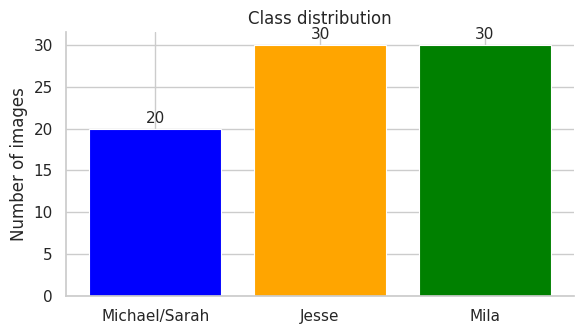

In [82]:
# Class distribution
print(train.groupby('name').agg({'img': 'count', 'class': 'max'}))
plot_class_distribution(train['class'].values, class_names={0:'Michael/Sarah',1:'Jesse',2:'Mila'})

In [83]:
# Image size statistics — check for dimension variation before choosing FACE_SIZE
train['h'] = train['img'].apply(lambda x: x.shape[0])
train['w'] = train['img'].apply(lambda x: x.shape[1])
train['aspect'] = train['w'] / train['h']
train[['h', 'w', 'aspect']].describe().round(2)

,h,w,aspect
count,80.00,80.00,80.00
mean,494.22,420.74,0.93
std,276.21,189.10,0.38
min,168.00,198.00,0.57
25%,360.00,300.00,0.67
50%,447.00,393.50,0.74
75%,594.00,480.00,1.06
max,2304.00,1536.00,2.08


## 0.3 Face detection & preprocessing

Raw images contain backgrounds, clothing, and sometimes multiple people.
We must isolate just the face region before extracting features — otherwise HOG and PCA and other methods
will describe the scene rather than the person.

### 0.3.1 Approach: HAAR vs DNN

We evaluated two OpenCV face detectors:

| Detector | Mechanism | False positives | Group shots |
|----------|-----------|-----------------|-------------|
| **HAAR** cascade | Hand-crafted edge filters | Many (shirts, walls) — required 7 post-filters | Struggles — no confidence score |
| **DNN** ResNet-SSD | Learned CNN features | Almost none — model rejects non-faces internally | Better — confidence score breaks ties |

Both detectors feed into the same scoring function:

```
score = confidence² × face_area × centre_weight × sharpness
```

- `confidence²`: DNN certainty, squared to make high-confidence detections dominate
- `face_area`: fraction of image covered — rewards prominent subjects
- `centre_weight`: Gaussian decay from rule-of-thirds target (35% from top) — portrait framing bias
- `sharpness`: Laplacian variance of the crop — foreground subjects are always sharper than background faces

At first we tried to make the HAAR mechanism better, but there were lots of wrong extracted faces, and the face extraction is very fundamental to the algorithm, we ended up not using this method to both get much better data to train our classifiers and extract better the faces when evaluating the classifier in the test set. <br>
**We use DNN for all experiments.**


In [84]:
# Our models support both HAAR and DNN detection, but we will only use DNN.
train_X_dnn,  train_y_dnn,  test_X  = run_preprocessing(
    train, test, detector='dnn',  face_size=FACE_SIZE,
    model_path='tmp', cache_path=None
)

if False: # ie disabled
    train_X_haar, train_y_haar, test_X_haar = run_preprocessing(
        train, test, detector='haar', face_size=FACE_SIZE,
        model_path='tmp', cache_path=None
    )

Using DNNFaceDetector ...
Preprocessing training set ...
Preprocessing test set ...
  train_X: (80, 150, 150, 3)  train_y: (80,)  test_X: (1816, 150, 150, 3)


**Limitations:**

- ~4 Jesse images contain Michael Cera at similar size and position — both detectors
  pick the wrong person because the other face scores higher on area + sharpness.
  These 4 samples (~5% of Jesse's training data) are accepted as label noise;
  classifiers trained on real-world data routinely handle this level of noise.
- One Mila image (HP billboard) returns no face — the center-crop fallback is used.

### 0.3.2 Face extraction and labelling on training data
The training dataset:
1. has images with multiple faces;
1. was very small, with little data for Michael and Sarah;
2. had faces of people who are not Mila, Jesse, Michael or Sarah; 
3. had images with no people/faces.

For these reasons, we tried to extract as many faces as possible from the images: Jesse, Mila, Michael and Sarah and new class called 'Other'. The 'Other' class contains faces from other people as well as erronous crops from the DNN algorithm (which sometimes create a crop that contains no faces). This creates a diverse 'other' category for the classifiers.

We built a function to manually extract the faces from the pictures that were not picked up from the face extractor and label them. The results were later saved into a .csv file called annotations.csv (hardcoded below for the submission notebook). 

Our final extracted training dataset contains 102 face crops.

In [85]:
# Embed the CSV Data in the notebook for easy access and reproducibility.
# We store the entire contents of the CSV as a multi-line string
ANNOTATIONS_CSV_DATA = """original_file,face_index,saved_crop_path,csv_name,csv_class,manual_label
train_0.npy,0,extracted_faces/train_0_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_1.npy,0,extracted_faces/train_1_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_2.npy,0,extracted_faces/train_2_face_0.jpg,Michael_Cera,0,Michael_Cera
train_3.npy,0,extracted_faces/train_3_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_4.npy,0,extracted_faces/train_4_face_0.jpg,Michael_Cera,0,Michael_Cera
train_5.npy,0,extracted_faces/train_5_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_6.npy,0,extracted_faces/train_6_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_7.npy,0,extracted_faces/train_7_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_8.npy,0,extracted_faces/train_8_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_9.npy,0,extracted_faces/train_9_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_10.npy,0,extracted_faces/train_10_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_11.npy,0,extracted_faces/train_11_face_0.jpg,Sarah_Hyland,0,Sarah_Hyland
train_12.npy,0,extracted_faces/train_12_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_13.npy,0,extracted_faces/train_13_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_14.npy,0,extracted_faces/train_14_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_15.npy,0,extracted_faces/train_15_face_0.jpg,Michael_Cera,0,Michael_Cera
train_16.npy,0,extracted_faces/train_16_face_0.jpg,Michael_Cera,0,Michael_Cera
train_17.npy,0,extracted_faces/train_17_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_18.npy,0,extracted_faces/train_18_face_0.jpg,Jesse_Eisenberg,1,Michael_Cera
train_18.npy,1,extracted_faces/train_18_face_1.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_19.npy,0,extracted_faces/train_19_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_20.npy,0,extracted_faces/train_20_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_21.npy,0,extracted_faces/train_21_face_0.jpg,Sarah_Hyland,0,Sarah_Hyland
train_22.npy,0,extracted_faces/train_22_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_22.npy,1,extracted_faces/train_22_face_1.jpg,Jesse_Eisenberg,1,Other
train_23.npy,0,extracted_faces/train_23_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_24.npy,0,extracted_faces/train_24_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_25.npy,0,extracted_faces/train_25_face_0.jpg,Michael_Cera,0,Michael_Cera
train_25.npy,1,extracted_faces/train_25_face_1.jpg,Michael_Cera,0,Other
train_26.npy,0,extracted_faces/train_26_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_27.npy,0,extracted_faces/train_27_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_28.npy,0,extracted_faces/train_28_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_28.npy,1,extracted_faces/train_28_face_1.jpg,Mila_Kunis,2,Other
train_29.npy,0,extracted_faces/train_29_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_29.npy,1,extracted_faces/train_29_face_1.jpg,Mila_Kunis,2,Other
train_30.npy,0,extracted_faces/train_30_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_30.npy,1,extracted_faces/train_30_face_1.jpg,Mila_Kunis,2,Mila_Kunis
train_31.npy,0,extracted_faces/train_31_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_32.npy,0,extracted_faces/train_32_face_0.jpg,Sarah_Hyland,0,Sarah_Hyland
train_32.npy,1,extracted_faces/train_32_face_1.jpg,Sarah_Hyland,0,Sarah_Hyland
train_33.npy,0,extracted_faces/train_33_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_34.npy,0,extracted_faces/train_34_face_0.jpg,Jesse_Eisenberg,1,Michael_Cera
train_34.npy,1,extracted_faces/train_34_face_1.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_34.npy,2,extracted_faces/train_34_face_2.jpg,Jesse_Eisenberg,1,Other
train_35.npy,0,extracted_faces/train_35_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_36.npy,0,extracted_faces/train_36_face_0.jpg,Sarah_Hyland,0,Sarah_Hyland
train_37.npy,0,extracted_faces/train_37_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_38.npy,0,extracted_faces/train_38_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_39.npy,0,extracted_faces/train_39_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_39.npy,1,extracted_faces/train_39_face_1.jpg,Mila_Kunis,2,Other
train_40.npy,0,extracted_faces/train_40_face_0.jpg,Mila_Kunis,2,Other
train_40.npy,1,extracted_faces/train_40_face_1.jpg,Mila_Kunis,2,Mila_Kunis
train_41.npy,0,extracted_faces/train_41_face_0.jpg,Michael_Cera,0,Michael_Cera
train_41.npy,1,extracted_faces/train_41_face_1.jpg,Michael_Cera,0,Other
train_42.npy,0,extracted_faces/train_42_face_0.jpg,Sarah_Hyland,0,Sarah_Hyland
train_43.npy,0,extracted_faces/train_43_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_44.npy,0,extracted_faces/train_44_face_0.jpg,Michael_Cera,0,Michael_Cera
train_45.npy,0,extracted_faces/train_45_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_46.npy,0,extracted_faces/train_46_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_47.npy,0,extracted_faces/train_47_face_0.jpg,Sarah_Hyland,0,Sarah_Hyland
train_48.npy,0,extracted_faces/train_48_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_49.npy,0,extracted_faces/train_49_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_49.npy,1,extracted_faces/train_49_face_1.jpg,Jesse_Eisenberg,1,Other
train_50.npy,0,extracted_faces/train_50_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_50.npy,1,extracted_faces/train_50_face_1.jpg,Mila_Kunis,2,Other
train_51.npy,0,extracted_faces/train_51_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_52.npy,0,extracted_faces/train_52_face_0.jpg,Jesse_Eisenberg,1,Other
train_52.npy,1,extracted_faces/train_52_face_1.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_53.npy,0,extracted_faces/train_53_face_0.jpg,Jesse_Eisenberg,1,Other
train_53.npy,1,extracted_faces/train_53_face_1.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_54.npy,0,extracted_faces/train_54_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_55.npy,0,extracted_faces/train_55_face_0.jpg,Sarah_Hyland,0,Sarah_Hyland
train_56.npy,0,extracted_faces/train_56_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_57.npy,0,extracted_faces/train_57_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_57.npy,1,extracted_faces/train_57_face_1.jpg,Mila_Kunis,2,Mila_Kunis
train_58.npy,0,extracted_faces/train_58_face_0.jpg,Sarah_Hyland,0,Sarah_Hyland
train_59.npy,0,extracted_faces/train_59_face_0.jpg,Sarah_Hyland,0,Other
train_59.npy,1,extracted_faces/train_59_face_1.jpg,Sarah_Hyland,0,Sarah_Hyland
train_60.npy,0,extracted_faces/train_60_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_61.npy,0,extracted_faces/train_61_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_61.npy,1,extracted_faces/train_61_face_1.jpg,Mila_Kunis,2,Other
train_62.npy,0,extracted_faces/train_62_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_63.npy,0,extracted_faces/train_63_face_0.jpg,Sarah_Hyland,0,Sarah_Hyland
train_64.npy,0,extracted_faces/train_64_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_65.npy,0,extracted_faces/train_65_face_0.jpg,Mila_Kunis,2,Other
train_66.npy,0,extracted_faces/train_66_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_67.npy,0,extracted_faces/train_67_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_68.npy,0,extracted_faces/train_68_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_69.npy,0,extracted_faces/train_69_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_70.npy,0,extracted_faces/train_70_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_70.npy,1,extracted_faces/train_70_face_1.jpg,Jesse_Eisenberg,1,Other
train_70.npy,2,extracted_faces/train_70_face_2.jpg,Jesse_Eisenberg,1,Other
train_71.npy,0,extracted_faces/train_71_face_0.jpg,Michael_Cera,0,Michael_Cera
train_72.npy,0,extracted_faces/train_72_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_73.npy,0,extracted_faces/train_73_face_0.jpg,Jesse_Eisenberg,1,Jesse_Eisenberg
train_74.npy,0,extracted_faces/train_74_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_75.npy,0,extracted_faces/train_75_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_76.npy,0,extracted_faces/train_76_face_0.jpg,Michael_Cera,0,Michael_Cera
train_77.npy,0,extracted_faces/train_77_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_77.npy,1,extracted_faces/train_77_face_1.jpg,Mila_Kunis,2,Mila_Kunis
train_78.npy,0,extracted_faces/train_78_face_0.jpg,Mila_Kunis,2,Mila_Kunis
train_79.npy,0,extracted_faces/train_79_face_0.jpg,Michael_Cera,0,Michael_Cera"""

In [86]:

# Create a reverse mapping from label string to integer for easy lookup
label_to_int = {v: k for k, v in CLASS_NAMES.items()}

# io.StringIO tricks pandas into reading the multi-line string just like a real file
df = pd.read_csv(io.StringIO(ANNOTATIONS_CSV_DATA.strip()))

original_images = []
extracted_faces = []
labels = []

for _, row in df.iterrows():
    orig_file = row['original_file']     
    crop_path = row['saved_crop_path']
    label_str = row['manual_label']

    orig_path = os.path.join(DATASET_FOLDER, orig_file)

    # Only load if both the original file and your new crop exist
    if os.path.exists(orig_path) and pd.notna(crop_path) and os.path.exists(crop_path):
        
        # Load Original Image (.npy is BGR, convert to RGB)
        img_bgr = np.load(orig_path, allow_pickle=False)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        original_images.append(img_rgb)

        # Load Extracted Crop (.jpg is BGR, convert to RGB)
        crop_bgr = cv2.imread(crop_path)
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        extracted_faces.append(crop_rgb)

        # Convert label back to integer (e.g., "Mila_Kunis" -> 2)
        labels.append(label_to_int[label_str])

# Prepare data for training and visualization
train_original = pd.DataFrame({'img': original_images}) # for graph below
X_train_relabelled = np.array(extracted_faces)
y_train_relabelled = np.array(labels)

print(f"Successfully loaded {len(X_train_relabelled)} annotated samples.")
print(f"As a reminder, initially we had {len(train)} images.")

Successfully loaded 102 annotated samples.
As a reminder, initially we had 80 images.


## 0.4 Verify extracted faces and update labels

We visually inspect the extracted crops for each class to confirm the detector is
selecting the correct person.  

When multiple faces are detected in an image, we label and save each face separately to augment the data. This also applies when no face is detected.


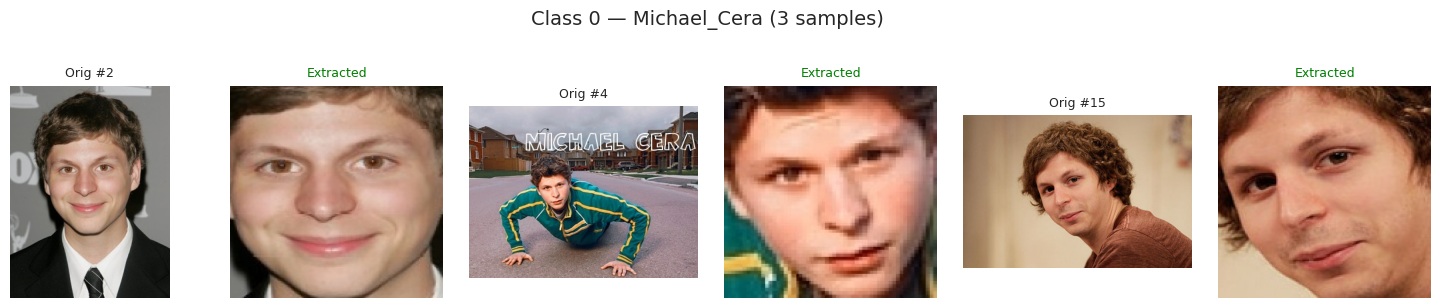

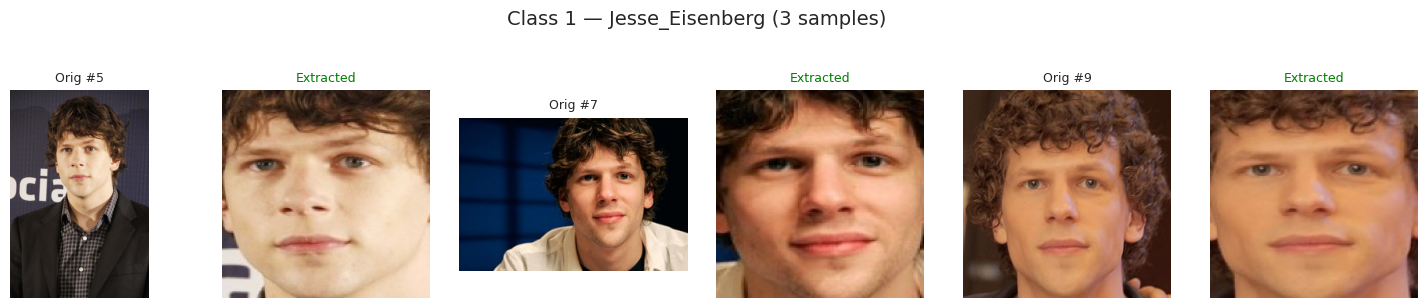

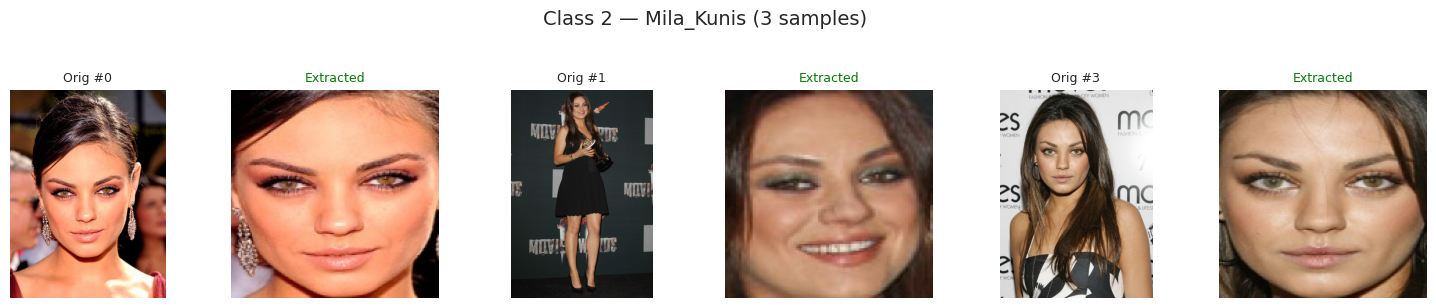

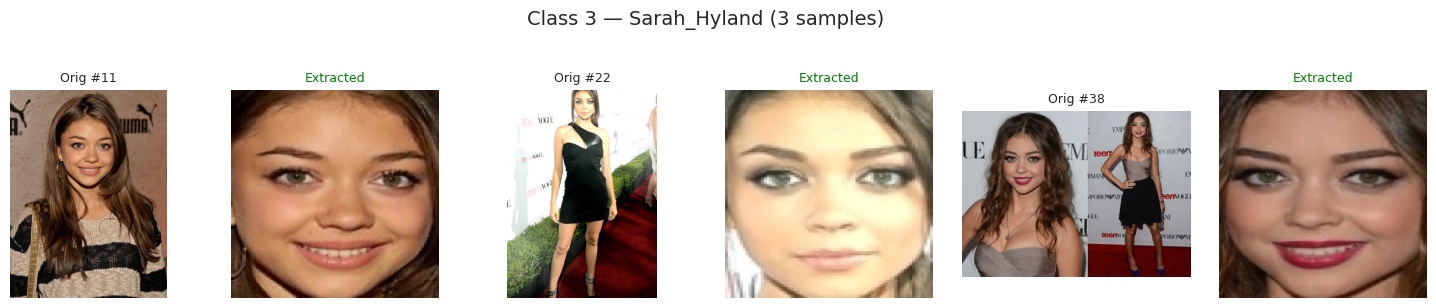

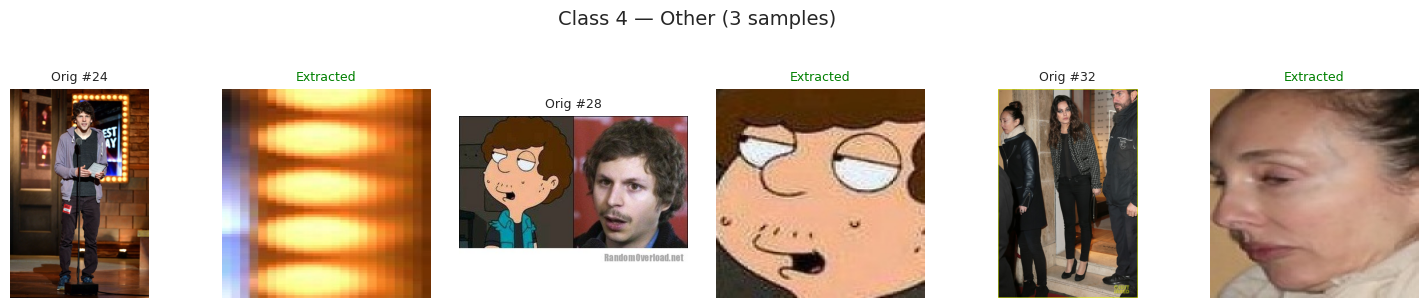

In [87]:
for class_id in sorted(CLASS_NAMES.keys()):
    n = 3  # Number of samples to show per class
    
    plot_original_vs_crop(train_original, X_train_relabelled, y_train_relabelled,
                        class_id=class_id, n=n, class_names=CLASS_NAMES)

## 0.5 Augment training data

We expand the training set by creating randomised versions of every original face. For each image, it generates extra copies by randomly applying horizontal flips (mirroring), adjusting the lighting (using brightness shifts or contrast enhancement), performing slight geometric tweaks like small rotations or scaling and possibly cutting part of the image.

In [88]:
def augment(images, labels, num_variants=2):
    """
    Creates exactly (1 + num_variants) images per original image.
    Uses randomized combinations of mirroring, lighting, and geometric shifts
    so the dataset doesn't explode in size.
    """
    aug_X, aug_y = [], []
    h, w = images[0].shape[:2]
    center = (w // 2, h // 2)

    # Setup CLAHE
    clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    for img, label in zip(images, labels):
        # 1. Always keep the clean original
        aug_X.append(img)
        aug_y.append(label)

        # 2. Generate exactly 'num_variants' additional augmented copies
        for _ in range(num_variants):
            aug_img = img.copy()

            # --- A. Random Mirror (50% chance) ---
            if random.choice([True, False]):
                aug_img = cv2.flip(aug_img, 1)

            # --- B. Random Lighting (Choose one: CLAHE, Dark, Light, or None) ---
            light_choice = random.choice(["clahe", "dark", "light", "none"])
            
            aug_img_uint8 = np.clip(aug_img, 0, 255).astype(np.uint8)
            
            if light_choice == "clahe":
                if len(aug_img_uint8.shape) == 3:
                    lab = cv2.cvtColor(aug_img_uint8, cv2.COLOR_RGB2LAB)
                    l, a, b = cv2.split(lab)
                    cl = clahe_obj.apply(l)
                    limg = cv2.merge((cl, a, b))
                    aug_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
                else:
                    aug_img = clahe_obj.apply(aug_img_uint8)
                    
            elif light_choice in ["dark", "light"]:
                gamma = 0.7 if light_choice == "dark" else 1.3
                invGamma = 1.0 / gamma
                table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
                aug_img = cv2.LUT(aug_img_uint8, table)

            # --- C. Random Geometric (Rotate, Scale, or None) ---
            geo_choice = random.choice(["rotate", "scale", "none"])
            
            if geo_choice == "rotate":
                angle = random.choice([-8, -4, 4, 8])
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                # BORDER_REPLICATE prevents black edges that ruin gradients
                aug_img = cv2.warpAffine(aug_img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
                
            elif geo_choice == "scale":
                scale = random.choice([0.9, 1.1])
                M = cv2.getRotationMatrix2D(center, 0, scale)
                aug_img = cv2.warpAffine(aug_img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

            # Append the newly crafted variant
            aug_X.append(aug_img)
            aug_y.append(label)

    return np.array(aug_X), np.array(aug_y)

X_train_final, y_train_final = augment(X_train_relabelled, y_train_relabelled)

## 0.6 Prepare face data for identification

The variables below will be used in our experiments.

In [89]:
train_X_gray = np.stack([
    cv2.resize(cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY), TARGET_SIZE) 
    for img in X_train_final
])

test_X_gray = np.stack([
    cv2.resize(cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY), TARGET_SIZE) 
    for img in test_X
])
train_X_flat = train_X_gray.reshape(train_X_gray.shape[0], -1)
test_X_flat = test_X_gray.reshape(test_X_gray.shape[0], -1)

# Quick dataset summary — confirms shapes and flags any remaining NaN crops
summarize_dataset(X_train_final, y_train_final, class_names=CLASS_NAMES)
# These are the final arrays we'll use for training!

Dataset summary:
  Total samples : 306
  Image shape   : (150, 150, 3)
  dtype         : uint8
  NaN crops     : 0
  Class counts  :
    0 — Michael_Cera: 36
    1 — Jesse_Eisenberg: 90
    2 — Mila_Kunis: 96
    3 — Sarah_Hyland: 33
    4 — Other: 51


---
# 1. Feature representations

A good feature representation must be both **robust** (same features extracted from
the same person under different conditions) and **discriminative** (different people
are easily separated in feature space).

We explore two paradigms:
- **Handcrafted**: HOG — encodes local gradient structure
- **Learned from data**: PCA / Eigenfaces — learns axes of maximum variation from the training set

We use the following class as basis to build HOG and PCA in the following sections.

In [90]:
class IdentityFeatureExtractor:
    """
    Baseline extractor — returns the raw input unchanged.
    Used with the random classifier in section 4.0 to establish a
    performance floor before any real feature engineering.
    """
    def transform(self, X): return X
    def __call__(self, X):  return self.transform(X)

## 1.1 Handcrafted features: HOG

**Histogram of Oriented Gradients (HOG)** computes the distribution of gradient
directions in local image regions.  It captures edge structure (eye sockets, nose
bridge, jawline) while being robust to small lighting changes through block-level
L2 normalisation.

In [91]:
class HOGFeatureExtractor(IdentityFeatureExtractor):
    def __init__(
        self,
        orientations:    int   = 9,
        pixels_per_cell: tuple = (8, 8),
        cells_per_block: tuple = (2, 2),
        target_size:     tuple = (64, 64),
        preprocessing:   list  = None,
        color_hog:       bool  = False,
    ):
        self.target_size   = target_size
        self.color_hog     = color_hog
        self.preprocessing = preprocessing if preprocessing is not None else ["clahe"]
        
        self.params = {
            "orientations":    orientations,
            "pixels_per_cell": pixels_per_cell,
            "cells_per_block": cells_per_block,
            "block_norm":      "L2-Hys",
            "visualize":       False,
        }
        self._clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def _apply_preprocessing(self, gray: np.ndarray) -> np.ndarray:
        result = gray.copy()
        for step in self.preprocessing:
            if step == "clahe": result = self._clahe.apply(result)
            elif step == "equalize": result = cv2.equalizeHist(result)
            elif step == "denoise": result = cv2.GaussianBlur(result, (3, 3), 0.8)
        return result

    def transform(self, img_array: np.ndarray) -> np.ndarray:
        # Transformation is 100% deterministic.
        if self.color_hog:
            img_uint8 = np.clip(img_array, 0, 255).astype(np.uint8)
            img_resized = cv2.resize(img_uint8, self.target_size)
            features = [hog(self._apply_preprocessing(img_resized[:,:,i]), **self.params) for i in range(3)]
            return np.concatenate(features).astype(np.float32)
        else:
            gray = face_to_gray(img_array, target_size=self.target_size)
            return hog(self._apply_preprocessing(gray), **self.params).astype(np.float32)

    def plot_hog_features(
        self,
        face_array: np.ndarray,
        label_array: np.ndarray,
        n_per_class: int = 2,
        class_names: dict = None,
        pairs_per_row: int = 3,
    ) -> None:
        """
        For each class shows *n_per_class* faces and their HOG visualisations.
        Uses the exact parameters and preprocessing defined in this extractor instance.
        """
        class_names = CLASS_NAMES
        classes = sorted(np.unique(label_array))
        
        # 1. Gather items to plot
        plot_items = []
        for cls in classes:
            indices = np.where(label_array == cls)[0][:n_per_class]
            label = class_names.get(cls, str(cls))
            
            try:
                colour = CLASS_COLOURS.get(cls, "black")
            except NameError:
                colour = "black"
                
            for idx in indices:
                plot_items.append((idx, label, colour))

        n_total = len(plot_items)
        if n_total == 0:
            print("No samples found to plot.")
            return

        # 2. Create Grid Layout
        num_rows = math.ceil(n_total / pairs_per_row)
        actual_cols = min(n_total, pairs_per_row) * 2 
        
        fig, axes = plt.subplots(num_rows, actual_cols, figsize=(2.5 * actual_cols, 3 * num_rows))
        
        if isinstance(axes, np.ndarray):
            axes = axes.flatten()
        else:
            axes = [axes]

        fig.suptitle(f"HOG Visualisation (Target Size: {self.target_size})", fontsize=14, y=1.02)

        for ax in axes:
            ax.axis("off")

        # 3. Plot Preprocessed Images & Features
        for i, (idx, label, colour) in enumerate(plot_items):
            img_ax = axes[2 * i]      
            hog_ax = axes[2 * i + 1]  
            
            img = face_array[idx]
            
            if np.isnan(img).any():
                img_ax.text(0.5, 0.5, "No face", ha="center", va="center", color="red")
                img_ax.set_title("Detection Failed", fontsize=9, color="red")
                continue

            # Step A: Convert to grayscale and resize exactly as the transform() method does
            if self.color_hog:
                # Even for color HOG, visualizing a single grayscale representation 
                # is best to understand the shapes it finds.
                gray_img = cv2.cvtColor(np.clip(img, 0, 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
                gray_img = cv2.resize(gray_img, self.target_size)
            else:
                gray_img = face_to_gray(img, target_size=self.target_size)

            # Step B: Apply the instance's specific preprocessing (e.g. CLAHE)
            preprocessed_img = self._apply_preprocessing(gray_img)

            # Step C: Calculate HOG using self.params, dynamically turning on visualize
            vis_params = {**self.params, "visualize": True}
            _, hog_img = hog(preprocessed_img, **vis_params)

            # Plot Preprocessed Face
            img_ax.imshow(preprocessed_img, cmap="gray")
            img_ax.set_title(f"{label} — input", fontsize=9, color=colour)

            # Plot HOG
            hog_ax.imshow(hog_img, cmap="magma")
            hog_ax.set_title(f"{label} — HOG", fontsize=9, color=colour)

        plt.tight_layout()
        plt.show()

### 1.1.1 Benchmarking HOG approaches

We tested multiple parameter settings for HOG to find the one that performs best:

In [92]:

def evaluate_extractor(extractor, X_train_final, y_train_final):
    """
    Extracts HOG features for the full dataset, performs an 80/20 train/val split,
    evaluates a fixed SVM using 5-fold CV on the training set, and returns metrics.
    """
    # 1. Extract features for all images at once (faster)
    X_features = extract_hog_batch(X_train_final, extractor, verbose=False)

    # 2. Perform the train/validation split inside the function
    X_tr, X_va, y_train, y_val = train_test_split(
        X_features, y_train_final, test_size=0.2, stratify=y_train_final, random_state=42
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC(kernel="rbf", C=10, gamma="scale", random_state=42))
    ])

    # 3. 5-fold CV accuracy on the training set ONLY
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe, X_tr, y_train, cv=cv, scoring="accuracy")

    # 4. Final validation accuracy on the 20% holdout set
    pipe.fit(X_tr, y_train)
    val_acc = accuracy_score(y_val, pipe.predict(X_va))

    return {
        "cv_mean":    cv_scores.mean(),
        "cv_std":     cv_scores.std(),
        "val_acc":    val_acc,
        "feat_len":   X_features.shape[1],
    }

configs = [
    # ── Baseline ─────────────────────────────────────────────────────────────
    {
        "name":            "Baseline (8px, 9 ori, CLAHE)",
        "pixels_per_cell": (8, 8),
        "orientations":    9,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },
    # ── A. pixels_per_cell ───────────────────────────────────────────────────
    # Small cells (4px): 16×16 grid — captures fine detail like eyelashes,
    # lip edges. But very sensitive to alignment noise and generates a 7056-dim
    # vector — risk of overfitting with 60-70 training samples.
    {
        "name":            "A1. Fine cells (4px)",
        "pixels_per_cell": (4, 4),
        "orientations":    9,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },
    # Large cells (16px): 4×4 grid — coarse face structure only (head shape,
    # eye region). Very compact vector (144 dims) but loses facial fine detail.
    # Likely to confuse Jesse and Michael who differ mainly in subtle features.
    {
        "name":            "A2. Coarse cells (16px)",
        "pixels_per_cell": (16, 16),
        "orientations":    9,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },
    # ── B. orientations ──────────────────────────────────────────────────────
    # Fewer bins (6): 30° resolution — may miss diagonal edges (e.g. jawline
    # slope) that are important for identity. Faster but less discriminative.
    {
        "name":            "B1. Fewer orientations (6)",
        "pixels_per_cell": (8, 8),
        "orientations":    6,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },
    # More bins (12): 15° resolution — captures very fine edge angles.
    # Diminishing returns vs 9 bins; can overfit to pose variation.
    {
        "name":            "B2. More orientations (12)",
        "pixels_per_cell": (8, 8),
        "orientations":    12,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },
    # ── C. preprocessing ─────────────────────────────────────────────────────
    # No preprocessing: raw grayscale — establishes whether CLAHE actually
    # helps. If baseline beats this, CLAHE is earning its keep.
    {
        "name":            "C1. No preprocessing",
        "pixels_per_cell": (8, 8),
        "orientations":    9,
        "preprocessing":   [],
        "color_hog":       False,
    },
    # Equalise only: global contrast stretch — simpler than CLAHE.
    # Tends to over-amplify noise in smooth skin regions.
    {
        "name":            "C2. Global equalise",
        "pixels_per_cell": (8, 8),
        "orientations":    9,
        "preprocessing":   ["equalize"],
        "color_hog":       False,
    },
    # CLAHE + denoise: removes sensor noise before CLAHE to prevent
    # noise from being amplified into false edges.
    {
        "name":            "C3. CLAHE + denoise",
        "pixels_per_cell": (8, 8),
        "orientations":    9,
        "preprocessing":   ["denoise", "clahe"],
        "color_hog":       False,
    },
    # ── D. color HOG ─────────────────────────────────────────────────────────
    # Runs HOG on R, G, B separately and concatenates — 3× longer vector.
    # For identity classification color rarely helps (Jesse and Michael
    # have similar skin tone) but may help Mila vs Jesse (different complexion).
    {
        "name":            "D1. Color HOG",
        "pixels_per_cell": (8, 8),
        "orientations":    9,
        "preprocessing":   ["clahe"],
        "color_hog":       True,
    },

    # ── E. Combined best guesses ──────────────────────────────────────────────
    # Fine cells + more orientations: highest detail, highest risk of overfit
    {
        "name":            "E1. Fine + more orientations (12)",
        "pixels_per_cell": (4, 4),
        "orientations":    12,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },
    # Coarser cells + CLAHE+denoise: robust to noise, compact
    {
        "name":            "E2. Coarse + denoise + clahe",
        "pixels_per_cell": (16, 16),
        "orientations":    9,
        "preprocessing":   ["denoise", "clahe"],
        "color_hog":       False,
    },
]

# ── Run all configurations ───────────────────────────────────────────────────
print("Running HOG configuration experiments...\n")
results = []

# Ensure TARGET_SIZE is defined in your environment (e.g., TARGET_SIZE = (64, 64))
for cfg in configs:
    ext = HOGFeatureExtractor(
        orientations    = cfg["orientations"],
        pixels_per_cell = cfg["pixels_per_cell"],
        cells_per_block = (2, 2),
        target_size     = TARGET_SIZE,  
        preprocessing   = cfg["preprocessing"],
        color_hog       = cfg["color_hog"]
    )
    
    metrics = evaluate_extractor(ext, X_train_final, y_train_final)
    
    row = {"config": cfg["name"], **metrics}
    results.append(row)
    
    print(f"  {cfg['name']:<38} "
          f"CV: {metrics['cv_mean']*100:.1f}% ±{metrics['cv_std']*100:.1f}%  "
          f"Val: {metrics['val_acc']*100:.1f}%  "
          f"Dims: {metrics['feat_len']}")

results_df = pd.DataFrame(results).sort_values("cv_mean", ascending=False)

Running HOG configuration experiments...

  Baseline (8px, 9 ori, CLAHE)           CV: 90.2% ±3.7%  Val: 95.2%  Dims: 1764
  A1. Fine cells (4px)                   CV: 77.9% ±4.3%  Val: 83.9%  Dims: 8100
  A2. Coarse cells (16px)                CV: 89.4% ±3.9%  Val: 95.2%  Dims: 324
  B1. Fewer orientations (6)             CV: 91.0% ±4.0%  Val: 95.2%  Dims: 1176
  B2. More orientations (12)             CV: 89.0% ±4.4%  Val: 91.9%  Dims: 2352
  C1. No preprocessing                   CV: 89.8% ±3.6%  Val: 95.2%  Dims: 1764
  C2. Global equalise                    CV: 89.8% ±2.9%  Val: 91.9%  Dims: 1764
  C3. CLAHE + denoise                    CV: 88.5% ±3.3%  Val: 93.5%  Dims: 1764
  D1. Color HOG                          CV: 88.9% ±3.3%  Val: 91.9%  Dims: 5292
  E1. Fine + more orientations (12)      CV: 74.6% ±5.1%  Val: 83.9%  Dims: 10800
  E2. Coarse + denoise + clahe           CV: 88.5% ±2.4%  Val: 96.8%  Dims: 324


### 1.1.2 Parameter choices

We select the configuration that performs well in terms of cross validation and has a reasonable number of dimensions:

Parameter | Detail | Impact
|-----------|-------|--------|
Orientations | 9 | Provides 20° resolution per bin. This is the optimal balance for capturing facial curves (like the jawline) without making the data too complex.
Pixels per cell | (16, 16) | Acts as a spatial filter. Larger cells focus on global structures (eyes, nose, mouth) and ignore noisy fine details, helping the model generalize.
Cells per block | (2, 2) | Groups cells for contrast normalization. This makes the features robust to localized lighting changes, such as shadows cast across one side of the face.
Preprocessing | CLAHE + Denoise | Denoising removes sensor grain to prevent false edges, while CLAHE boosts local contrast, ensuring facial features stay sharp and visible even in poor lighting.
Colour | No | Reduces dimensionality. Facial geometry is primarily defined by intensity gradients; removing color speeds up training and prevents overfitting to skin tones.

**A benefit of this configuration is that it has a comparatively small dimension which makes computation faster and should improve generalisation.**

Below, we run our HOG feature extractor to visualise the results. Note that the input is always converted to **grayscale**, colour does not boost acuracy color adds and triples computation.

We compute the HOG which will be used for our experiments:

In [93]:
hog_ext = HOGFeatureExtractor(
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    target_size=TARGET_SIZE,
    preprocessing=["denoise", "clahe"],
    color_hog=False # Set to True if you want 3x more features
)

print("Extracting HOG features...")

train_hog_features = np.array([hog_ext.transform(x) for x in X_train_final])
test_hog_features  = np.array([hog_ext.transform(x) for x in test_X])

print(f"  Train HOG : {train_hog_features.shape} ")
print(f"  Test  HOG : {test_hog_features.shape}")

Extracting HOG features...
  Train HOG : (306, 324) 
  Test  HOG : (1816, 324)


### 1.1.3 HOG feature visualisation

The HOG image shows the dominant gradient direction in each cell.
For a valid face crop we expect to see structure around the eyes, nose, and mouth.
If the HOG image looks noisy or uniform, the face crop was a false positive.


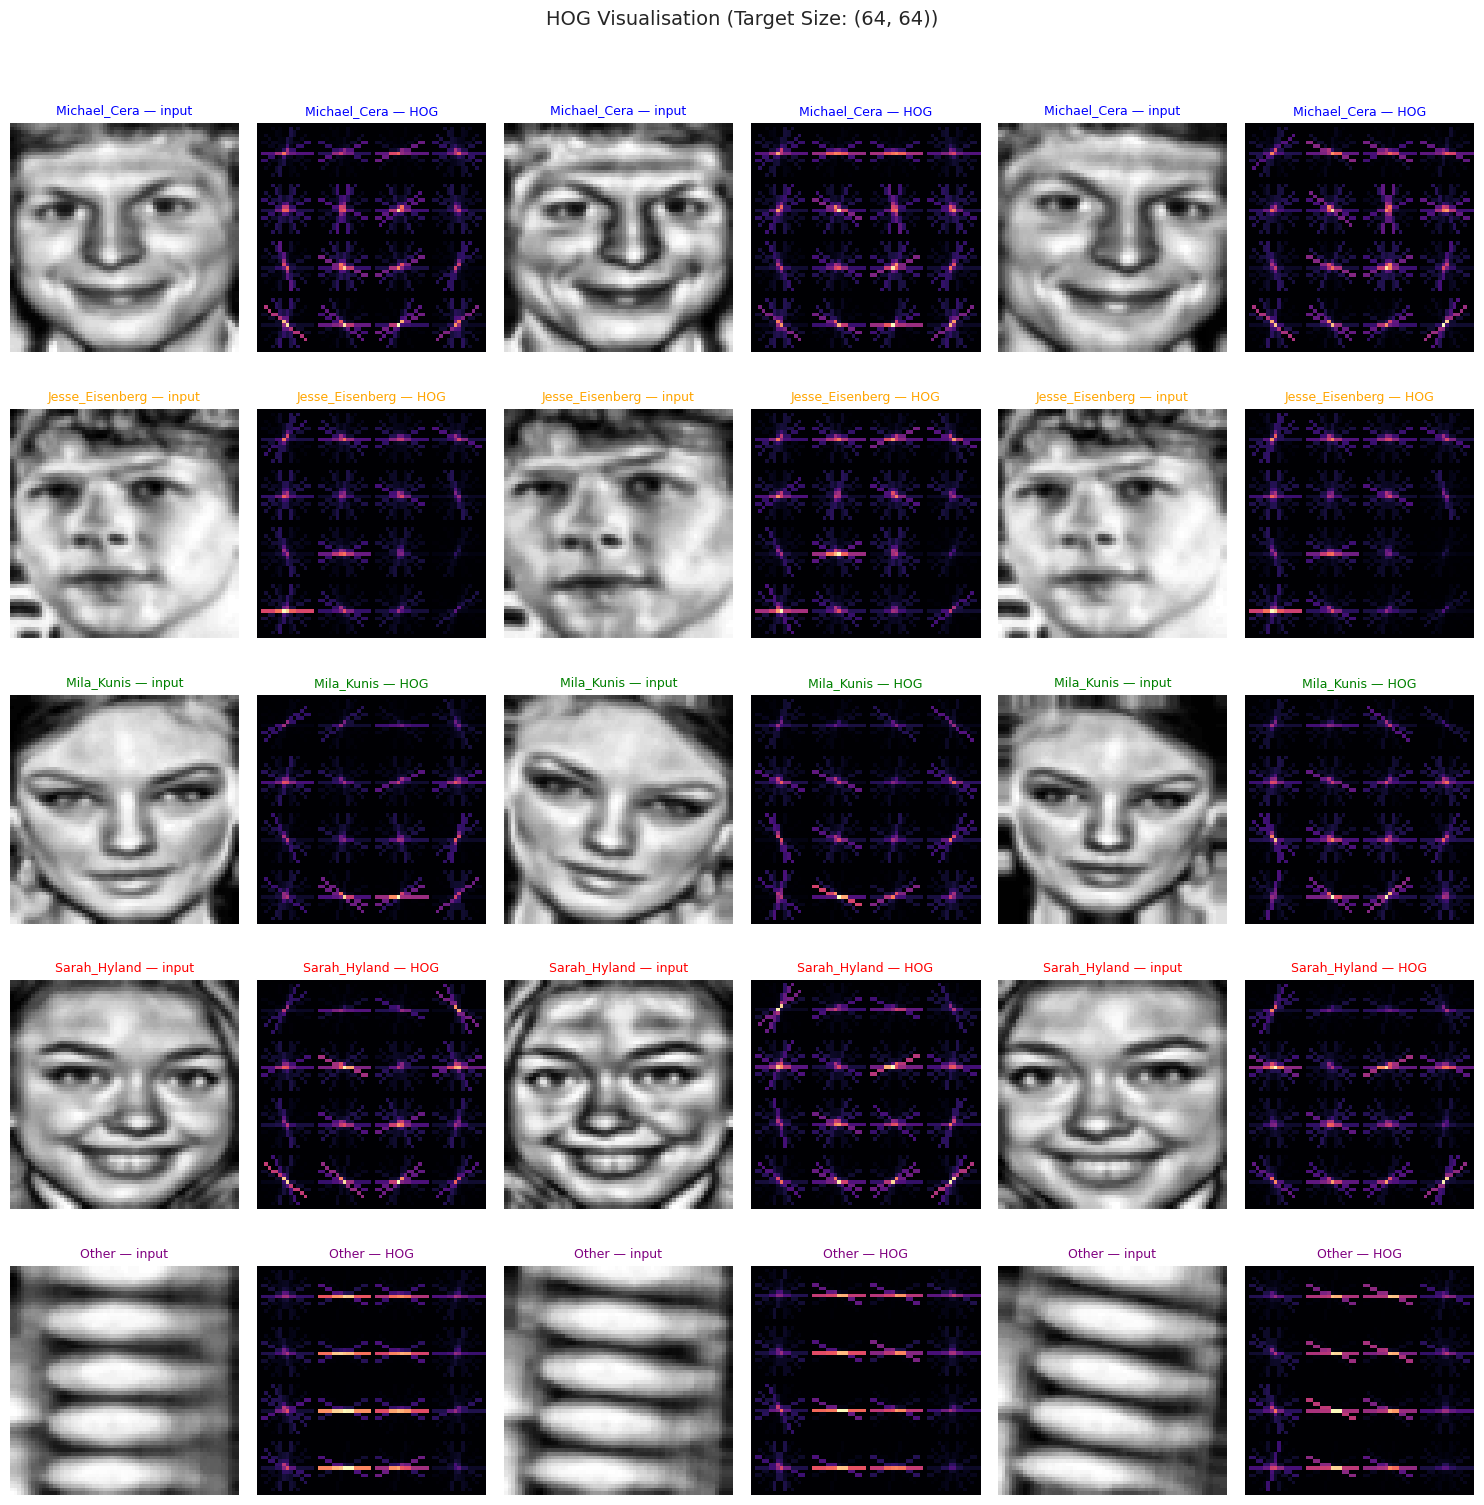

In [94]:
hog_ext.plot_hog_features(
    face_array=X_train_final, 
    label_array=y_train_final, 
    n_per_class=3, 
    pairs_per_row=3
)

### 1.1.4 t-SNE plot

t-SNE projects the high-dimensional HOG vectors to 2D so we can visually assess
whether the features are **discriminative** (classes form separate clusters) and
**robust** (same class forms a tight cluster despite image variation).

We use `perplexity=10` because with only 80 training samples the default of 30 is
too large — it would force every point to be considered a neighbour of every other.


Running t-SNE (perplexity=10) on (306, 324) ...


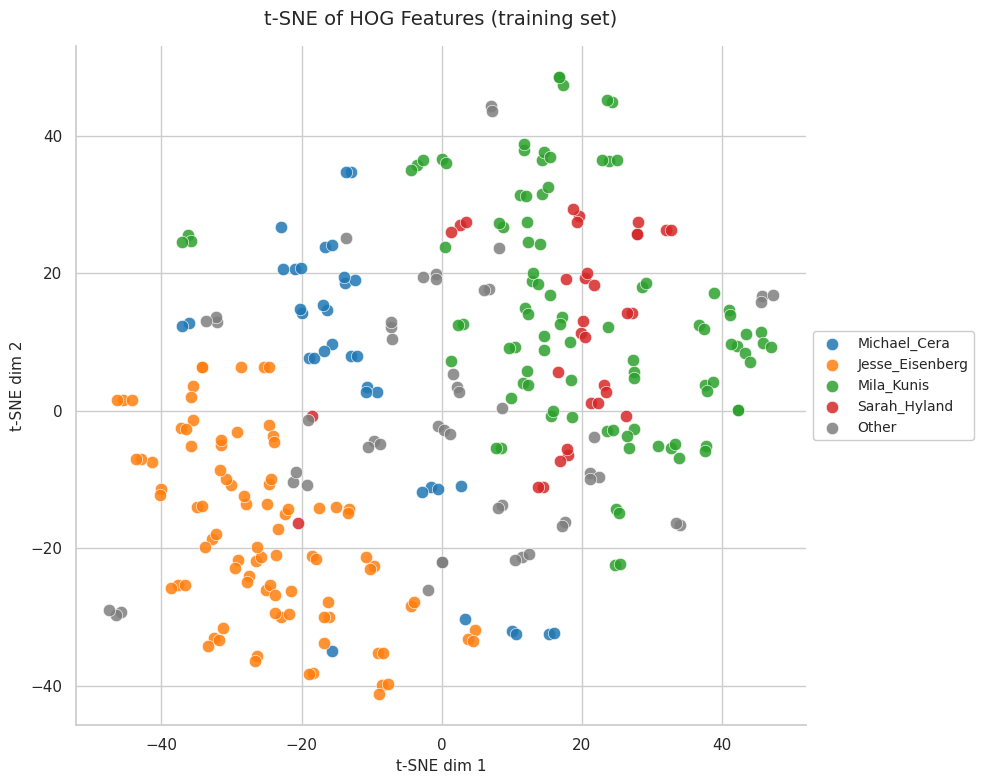

In [95]:
def plot_tsne(
    features: np.ndarray,
    label_array: np.ndarray,
    title: str = "t-SNE Feature Space",
    class_names: dict = None,
    perplexity: int = 10,
    random_state: int = 42,
) -> None:
    """
    2-D t-SNE scatter plot of *features* coloured by class with high-contrast distinct colors.
    """
    # Ensure class_names is a dictionary
    if isinstance(class_names, list):
        class_names = {i: name for i, name in enumerate(class_names)}
    elif class_names is None:
        class_names = {}

    print(f"Running t-SNE (perplexity={perplexity}) on {features.shape} ...")
    tsne = TSNE(
        n_components=2, perplexity=perplexity, random_state=random_state, max_iter=1000
    )
    coords = tsne.fit_transform(features)

    fig, ax = plt.subplots(figsize=(10, 8))
    classes = sorted(np.unique(label_array))

    # Define a custom, highly distinct color palette for up to 10 classes
    # We use a specific dark gray for the "Other" class (usually class 4)
    distinct_colors = {
        0: "#1f77b4",  # Blue (Michael)
        1: "#ff7f0e",  # Orange (Jesse)
        2: "#2ca02c",  # Green (Mila)
        3: "#d62728",  # Red (Sarah)
        4: "#7f7f7f",  # Gray (Other - makes it recede as background noise)
        5: "#9467bd",  # Purple
        6: "#8c564b",  # Brown
        7: "#e377c2",  # Pink
    }

    for i, cls in enumerate(classes):
        mask = label_array == cls

        # Grab the color from our distinct dictionary, or fall back to a random hex if we exceed 8 classes
        colour = distinct_colors.get(cls, f"#{np.random.randint(0, 0xFFFFFF):06x}")

        # Determine the label name
        label_name = class_names.get(cls, f"Class {cls}")

        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            c=colour,
            label=label_name,
            s=80,  # Made the dots slightly larger for better visibility
            alpha=0.85,
            edgecolors="white",
            linewidths=0.5,
        )

    # Move legend outside the plot so it doesn't cover up data points
    ax.legend(fontsize=10, framealpha=1.0, loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("t-SNE dim 1", fontsize=11)
    ax.set_ylabel("t-SNE dim 2", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

# t-SNE — assesses discriminability of HOG features
# Well-separated clusters = HOG captures class-specific facial structure
plot_tsne(
    features    = train_hog_features,
    label_array = y_train_final,
    title       = "t-SNE of HOG Features (training set)",
    class_names = CLASS_NAMES,
    perplexity  = 10,
)

### 1.1.5 Discussion
The t-SNE graph shows good separation between Jesse and Mila (orange and green dots). The HOG features are good at capturing the difference between the two persons. We also see that HOG features are also quite good for distinguishing Jesse and Michael (orange and blue dots). However, HOG features are less useful for separating Mila and Sarah (red dots in the middle of green dots). We expect HOG will struggle most to distinguish Mila and Sarah.

Comparison of HOG features (group assignment) and Grabbing (individual assignment):

Comparison | HOG Features | Grabbing
|-------|-------|--------|
Primary Goal | Describes shape and structure | Extracts pixels or regions
Sensitivity | Robust to lighting and color changes | Highly dependent on color and intensity
Output | A mathematical histogram of edge angles | A mask or a subset of the original pixels

A simplified analogy is that HOG tells us what is the geometry of the object while grabbing tells us which pixels belong to the object.

HOG is consequently much better at detecting faces than grabbing because it is robust to lightning changes, translation and noise.

## 1.2 Features learned from data: PCA / Eigenfaces

We use the class `PCAFeatureExtractor` to extract eigenface features from the face images.

**`fit(X)`**: Subtracts the mean face from every image so that the data is centered around zero. This is a required step before applying SVD, as PCA assumes the data is mean-centered. It then applies Singular Value Decomposition and stores the S vector (which contains the singular values, related to the eigenvalues of the covariance matrix) and the Vt matrix (whose rows are the principal components, i.e. the eigenfaces).

**`transform(X)`**: Projects images into the reduced PCA space by centering them with the same mean face and multiplying by the first `n_components` eigenfaces. Each image is represented as a compact feature vector of `n_components` values instead of thousands of pixels.

**`inverse_transform(X_projected)`**: Reconstructs images from their PCA representation back to pixel space by multiplying the coefficients by the eigenfaces and adding the mean face back. This is useful for visualizing how much information is retained at different numbers of components.

In [96]:
class PCAFeatureExtractor(IdentityFeatureExtractor):
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        self.mean_face = X.mean(axis=0)
        X_centered = X - self.mean_face
        U, self.S, self.Vt = np.linalg.svd(X_centered, full_matrices=False)

    def transform(self, X):
        return (X - self.mean_face) @ self.Vt[:self.n_components, :].T

    def inverse_transform(self, X_projected):
        return X_projected @ self.Vt[:self.n_components, :] + self.mean_face

### 1.2.1 Choosing the number of components

To determine how many principal components to retain, we analyse how much variance each component explains. The singular values from SVD tell us this. Specifically, the squared singular values are proportional to the eigenvalues of the covariance matrix. By dividing each squared singular value by the total sum, we get the percentage of variance explained by each component.

We plot these values in a scree plot and look for the "elbow", the point where the curve flattens and additional components stop contributing meaningful information.

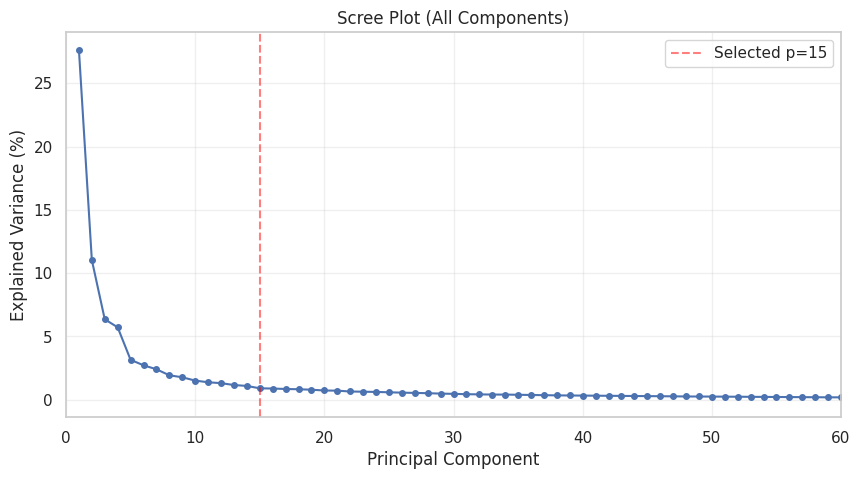

First 15 PCs explain: 70.12%
Total possible components: 306
Actually useful components (non-zero): 297


In [97]:
# 1. Initialize WITHOUT n_components to calculate all possible principal components
pca_extractor = PCAFeatureExtractor(n_components=None) 
pca_extractor.fit(train_X_flat)

# 2. Calculate the variance explained by each component
squared_s = pca_extractor.S ** 2
# Now the sum is truly the total variance in the dataset
explained_var = squared_s / squared_s.sum() * 100 

# 3. Plot the Scree Plot (We limit the x-axis to the first 60 for readability)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o', linestyle='-', markersize=4)

# Optional: Add a vertical line where you think the "elbow" is
plt.axvline(x=15, color='red', linestyle='--', alpha=0.5, label='Selected p=15')

plt.xlim(0, 60) # Zoom in on the interesting part
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot (All Components)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"First 15 PCs explain: {np.sum(explained_var[:15]):.2f}%")

# Compute how many components are different from zero
epsilon = 1e-10 
non_zero_count = np.sum(pca_extractor.S**2 > epsilon)

print(f"Total possible components: {len(pca_extractor.S)}")
print(f"Actually useful components (non-zero): {non_zero_count}")

The scree plot shows a clear elbow around 3-5 components, after which the individual contributions flatten out significantly. The first component alone explains more than 25% of the variance, and the first two together account for more than 35%. Beyond the first 10 components, each additional component contributes less than 2%.

The first 15 principal components explain ~70% of the total variance. We therefore treat p=15 as our initial choice and we will validate it empirically in the classification section by comparing performance across different values of p.

Although almost all PCs are different from zero, a few explain most variation in the images.

To validate empirically the 15 components, we benchmark using an RBF SVM, which we will see performs quite well later for PCA (fast and good predictions):

In [98]:
# Testing for different values of p
p_values = [2, 5, 10, 15, 20, 30, 40, 50, 60, 75]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=45)

results = []
for n_components in p_values:
    pca_eval = PCAFeatureExtractor(n_components=n_components)
    pca_eval.fit(train_X_flat)
    features = pca_eval.transform(train_X_flat)

    fold_accuracies = []
    for train_idx, val_idx in cv.split(features, y_train_final):
        X_train_cv, X_val_cv = features[train_idx], features[val_idx]
        y_train_cv, y_val_cv = y_train_final[train_idx], y_train_final[val_idx]

        # Initialize the sklearn SVC with RBF kernel directly
        # Defaults: kernel='rbf', C=1.0, gamma='scale'
        clf_cv = SVC(kernel='rbf', random_state=42)
        clf_cv.fit(X_train_cv, y_train_cv)
        y_pred_cv = clf_cv.predict(X_val_cv)
        
        fold_accuracies.append(accuracy_score(y_val_cv, y_pred_cv))

    mean_accuracy = np.mean(fold_accuracies)
    results.append((n_components, mean_accuracy))
    print(f"p={n_components:2d}, mean validation accuracy = {mean_accuracy:.4f}")

p= 2, mean validation accuracy = 0.6077
p= 5, mean validation accuracy = 0.6176
p=10, mean validation accuracy = 0.7514
p=15, mean validation accuracy = 0.7710
p=20, mean validation accuracy = 0.7972
p=30, mean validation accuracy = 0.7940
p=40, mean validation accuracy = 0.8170
p=50, mean validation accuracy = 0.8365
p=60, mean validation accuracy = 0.8398
p=75, mean validation accuracy = 0.8398


The cross-validation results confirm the choice of p=15 suggested by the scree 
plot elbow. While accuracy continues to fluctuate slightly beyond p=15, the 
improvements are marginal and inconsistent, indicating that the additional 
components do not carry reliably discriminative information. The plateau in 
accuracy beyond p=15 suggests that the remaining variance captured by higher 
components reflects noise or class-irrelevant variation (e.g. lighting, 
background) rather than identity-discriminative features. We therefore fix 
p=15 as our choice, consistent with both the elbow in the scree plot and 
the cross-validation evidence.

We therefore select 15 components to compute our PCA features, which we will then use in our experiments:

In [99]:
pca_final = PCAFeatureExtractor(n_components=15)
pca_final.fit(train_X_flat)
train_pca_features = pca_final.transform(train_X_flat)

### 1.2.2 Eigenface reconstructions

To visualize how much information is retained at different numbers of principal components, we reconstruct a single face image using an increasing number of eigenfaces (p = 1, 5, 10, 20, 40, 60, 75).

With p=1, the reconstruction is essentially the mean face with a slight adjustment in one direction of variation, the identity of the person is unrecognizable. By p=5, some facial structure begins to emerge. At p=10, the general shape and features become visible, and by p=20, the face is clearly recognizable as a specific individual. Beyond p=40, the added components contribute finer details such as skin texture and hair strands.


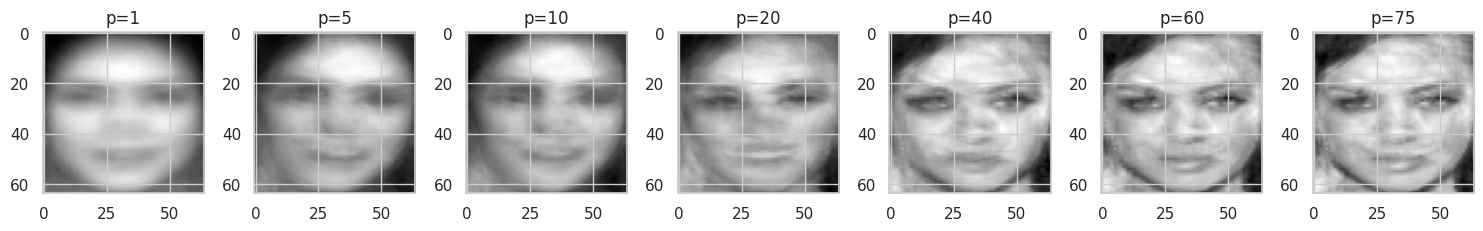

In [100]:
p = [1, 5, 10, 20, 40, 60, 75]
fig, axes = plt.subplots(1, len(p), figsize=(15, 4))
for i, p_val in enumerate(p):
    pca_temp = PCAFeatureExtractor(n_components=p_val)
    pca_temp.fit(train_X_flat)
    coefficients = pca_temp.transform(train_X_flat[0:1])
    reconstruction = pca_temp.inverse_transform(coefficients)
    side_length = int(np.sqrt(reconstruction.shape[-1]))
    axes[i].imshow(reconstruction.reshape(side_length, side_length), cmap='gray')
    axes[i].set_title(f'p={p_val}')
plt.tight_layout()
plt.show()

### 1.2.3 Feature space visualisation

To visualize how well PCA separates the different classes, we project all training images onto the first two principal components and plot them in a scatter plot, colored by class label. This gives us an intuitive view of whether the eigenface features can distinguish between the different identities, even though only two dimensions are used.

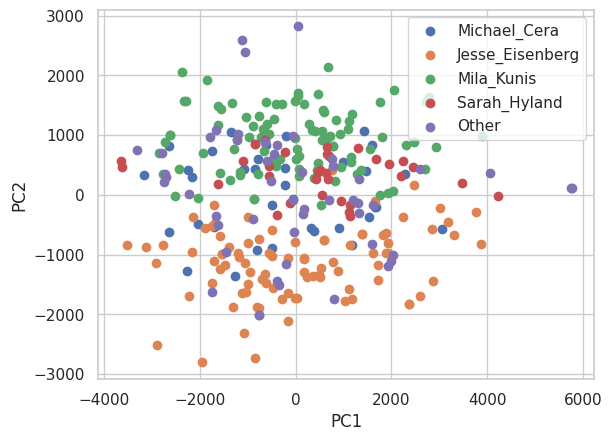

In [101]:
scatter = pca_extractor.transform(train_X_flat)
for cls, name in CLASS_NAMES.items():
    mask = y_train_final == cls
    plt.scatter(scatter[mask, 0], scatter[mask, 1], label=name)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

### 1.2.4 Discussion

Projecting the faces onto the first two principal components reveals some interesting patterns. There is a visible separation between Jesse and Mila, Jesse's images tend to cluster in the upper half of the plot while Mila's images are mostly in the lower half, particularly along PC2. This suggests that even with just two components, PCA captures some meaningful differences.

However, the "Neither" class (Michael Cera and Sarah Hyland) overlaps heavily with both Jesse and Mila. This makes sense, since Michael Cera looks similar to Jesse and Sarah Hyland looks similar to Mila — which is exactly why they were chosen for this dataset. A classifier using only these two features would likely confuse these look-alikes with their counterparts.

Overall, while two components show some discriminative power, they only explain around 35% of the total variance. Using more components for classification should improve separation, especially for distinguishing the look-alikes. This would also explain why the points are less separated when comparing to the HOG t-SNE plot.

# 2. Evaluation metrics

We use **Accuracy** as our primary evaluation metric because it provides a single, intuitive number representing the overall effectiveness of the classifier—essentially, what percentage of the total predictions were correct. It is particularly effective for this assignment because our reformulated 5-class training set is relatively balanced (see code below), meaning no single person or "Other" category overwhelmingly dominates the data.

However, we acknowledge that accuracy treats all errors equally; it doesn't distinguish between confusing Jesse with Michael (a lookalike) versus Jesse with Mila (a distinct subject). In our experiments below, we do verify using a Confusion Matrix that our models aren't achieving a high score simply by "guessing" the most frequent class.

In [102]:
summarize_dataset(X_train_final, y_train_final, class_names=CLASS_NAMES)

Dataset summary:
  Total samples : 306
  Image shape   : (150, 150, 3)
  dtype         : uint8
  NaN crops     : 0
  Class counts  :
    0 — Michael_Cera: 36
    1 — Jesse_Eisenberg: 90
    2 — Mila_Kunis: 96
    3 — Sarah_Hyland: 33
    4 — Other: 51


# 3. Classifiers

We will use the classifiers directly provided in python packages, mainly scikit-learn in our experiments below.

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  

Load data for experiments:

In [103]:
# 1. Use the labels and images already in memory
train_X_img = X_train_final.copy()

# 2. Use HOG features already calculated
train_X_hog = train_hog_features
    
# 3. Use PCA features already calculated
train_X_pca = train_pca_features

print(f"Training set shapes -> HOG: {train_X_hog.shape}, PCA: {train_X_pca.shape}, Images: {train_X_img.shape}, Labels: {y_train_final.shape}")

# 4. Pass HOG, PCA, and Images: the function splits all three using identical indices.
(X_train_hog, X_val_hog, 
 X_train_pca, X_val_pca, 
 X_train_img, X_val_img, 
 y_train, y_val) = get_train_val_split(
    train_X_hog, 
    train_X_pca,
    train_X_img, 
    labels=y_train_final, 
    test_size=0.15, 
    random_state=42,
    verbose=True  
)

Training set shapes -> HOG: (306, 324), PCA: (306, 15), Images: (306, 150, 150, 3), Labels: (306,)
get_train_val_split:
  Total samples  : 306
  Training       : 260
  Validation     : 46
  Train dist     : {0: 31, 1: 76, 2: 82, 3: 28, 4: 43}
  Val   dist     : {0: 5, 1: 14, 2: 14, 3: 5, 4: 8}


## 4.1 Benchmark classifiers for HOG and PCA

We test a wide range of classifiers on HOG and PCA. We find that an Multi-Layer Perceptron (MLP) performs best on HOG while a Random Forest performs best on PCA.

The Multi-Layer Perceptron (MLP) excels with HOG features because HOG provides a high-dimensional, structured representation of local edge gradients. Since HOG features possess spatial relationships and consistent patterns across the feature vector, the MLP's hidden layers can effectively learn non-linear combinations of these gradients to identify complex facial structures. Neural networks are naturally suited for these large, dense feature spaces where they can find subtle correlations that linear models or tree-based methods might miss.

Conversely, Random Forest performs best on PCA because PCA compresses the data into a small set of uncorrelated, ranked components. Each principal component represents a specific "eigen-variance" (like global lighting or head shape) that acts as a strong independent variable. Decision trees are highly efficient at making axis-aligned splits on these types of dense, low-dimensional features. Because the number of features is small and each one carries high information density, the ensemble of trees can quickly isolate the boundaries between classes without the risk of overfitting common in high-dimensional spaces.

In addition, we also see that SVMs perform quite well for both HOG and PCA.

In [104]:

# Filter out the specific deprecation warning from pkg_resources
warnings.filterwarnings("ignore", category=UserWarning, module='pkg_resources')
# Also common to ignore general DeprecationWarnings during benchmarks
warnings.filterwarnings("ignore", category=DeprecationWarning)

# ==========================================
# 1. Define the Benchmark Dictionary
# ==========================================
models = {
    "Linear SVM": LinearSVC(max_iter=100000, random_state=42),
    "RBF SVM": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=10000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "LDA (Fisherfaces)": LDA(),
    "Gaussian Process": GaussianProcessClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "Neural Net (MLP)": MLPClassifier(hidden_layer_sizes=(128,), max_iter=1000, random_state=42),
}

# Note: Because CV does the splitting for us, we pass the ENTIRE training arrays,
# not the pre-split X_train/X_val subsets.
datasets = {
    "HOG": train_X_hog,
    "PCA": train_X_pca
}

# Set up the Cross-Validation strategy (5 folds, keeping class balance)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 2. Run the Benchmark Loop
# ==========================================
print("\nStarting 5-Fold CV Benchmark (HOG vs PCA)...")
results = []

# Assuming train_y is your full label array loaded earlier
y_full = y_train_final 

for feature_name, X_full in datasets.items():
    
    for model_name, base_model in models.items():
        
        # cross_validate handles the cloning internally, but we clone just to be safe
        model = clone(base_model)
        
        try:
            # Run the 5-fold cross validation
            cv_results = cross_validate(
                estimator=model,
                X=X_full,
                y=y_full,
                cv=cv_strategy,
                scoring='accuracy',
                return_train_score=False,
                n_jobs=-1 # Use all CPU cores for speed
            )
            
            # Calculate means and standard deviations across the 5 folds
            mean_acc = np.mean(cv_results['test_score'])
            std_acc = np.std(cv_results['test_score'])
            mean_fit_time = np.mean(cv_results['fit_time'])
            mean_pred_time = np.mean(cv_results['score_time'])
            
            results.append({
                "Feature Set": feature_name,
                "Model": model_name,
                "Accuracy (%)": round(mean_acc * 100, 2),
                "Stability (±%)": round(std_acc * 100, 2),
                "Avg Train Time (s)": round(mean_fit_time, 4),
                "Avg Predict Time (s)": round(mean_pred_time, 4)
            })
            
        except Exception as e:
            print(f"     [!] {model_name} failed on {feature_name}: {str(e).split()[0]}...")
            continue # Skip to the next model if this one crashes

# ==========================================
# 3. Display the Leaderboard
# ==========================================
print("\n" + "="*95)
print("5-FOLD CV BENCHMARK RESULTS")
print("="*95)

# Convert to Pandas DataFrame and sort by Accuracy
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["Feature Set", "Accuracy (%)", "Stability (±%)"], ascending=[True, False, True]).reset_index(drop=True)

print(results_df.to_string())
print("="*95)


Starting 5-Fold CV Benchmark (HOG vs PCA)...
     [!] XGBoost failed on HOG: All...
     [!] XGBoost failed on PCA: All...

5-FOLD CV BENCHMARK RESULTS
   Feature Set                Model  Accuracy (%)  Stability (±%)  Avg Train Time (s)  Avg Predict Time (s)
0          HOG     Neural Net (MLP)         86.58            4.48              0.5474                0.0007
1          HOG  K-Nearest Neighbors         83.99            3.18              0.0007                0.0062
2          HOG              RBF SVM         83.00            3.05              0.0056                0.0022
3          HOG           Linear SVM         83.00            4.61              0.0566                0.0006
4          HOG        Random Forest         81.05            2.39              0.3124                0.0343
5          HOG  Logistic Regression         80.06            3.51              0.0227                0.0005
6          HOG     Gaussian Process         74.19            3.45              0.0606      

## 4.2 HOG vs PCA using LinearSVM

We present a more detailed comparison of the performance of HOG and PCA using a classifier that performs quite well with both approaches: 

Training on HOG features...
Training on PCA features...


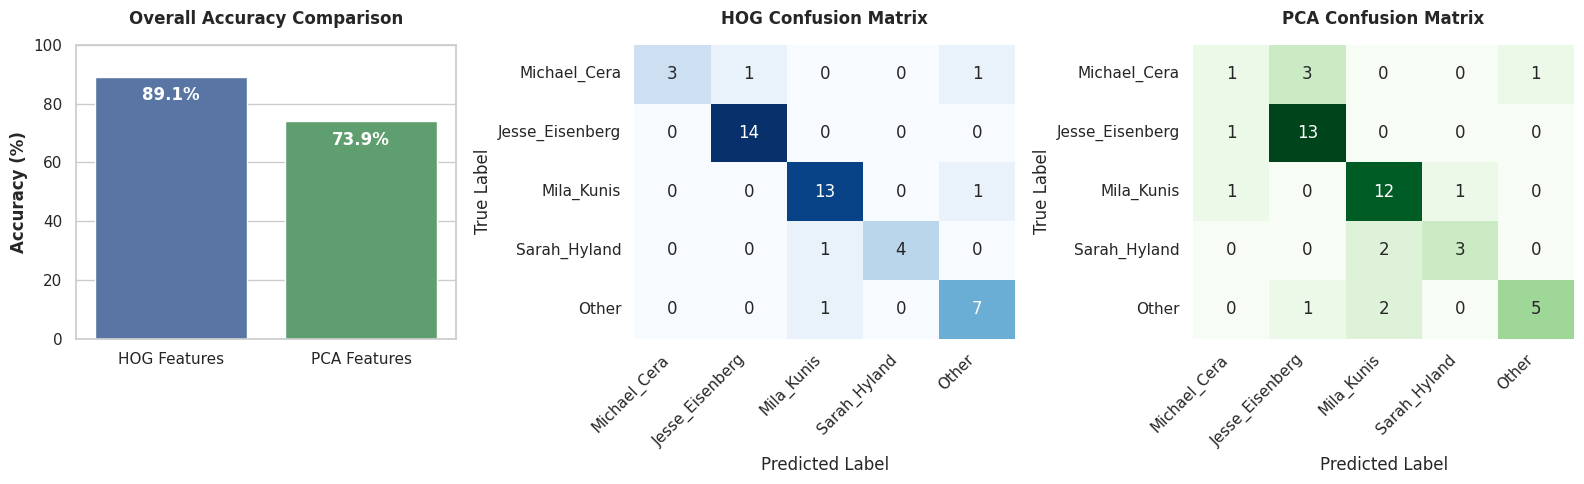

In [105]:

# ==========================================
# Train and Predict on HOG
# ==========================================
print("Training on HOG features...")
model_hog = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_hog.fit(X_train_hog, y_train)
y_val_pred_hog = model_hog.predict(X_val_hog)
acc_hog = accuracy_score(y_val, y_val_pred_hog)

# ==========================================
# Train and Predict on PCA
# ==========================================
print("Training on PCA features...")
model_pca = clone(model_hog) # Clone to ensure a fresh, untrained model
model_pca.fit(X_train_pca, y_train)
y_val_pred_pca = model_pca.predict(X_val_pca)
acc_pca = accuracy_score(y_val, y_val_pred_pca)

# ==========================================
# Generate Comparison Plots
# ==========================================
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(16, 5))

# Plot A: Accuracy Bar Chart
ax1 = plt.subplot(1, 3, 1)
feature_names = ['HOG Features', 'PCA Features']
accuracies = [acc_hog * 100, acc_pca * 100]

sns.barplot(
    x=feature_names, 
    y=accuracies, 
    hue=feature_names,
    palette=['#4C72B0', '#55A868'], 
    legend=False,
    ax=ax1
)

ax1.set_ylim(0, 100)
ax1.set_ylabel('Accuracy (%)', fontweight='bold')
ax1.set_title('Overall Accuracy Comparison', fontweight='bold', pad=15)

for i, v in enumerate(accuracies):
    ax1.text(i, v - 8, f"{v:.1f}%", color='white', ha='center', fontweight='bold', fontsize=12)

# Extract string labels for the heatmaps
tick_labels = list(CLASS_NAMES.values())

# Calculate Confusion Matrices
cm_hog = confusion_matrix(y_val, y_val_pred_hog)
cm_pca = confusion_matrix(y_val, y_val_pred_pca)

# Plot B: HOG Confusion Matrix
ax2 = plt.subplot(1, 3, 2)
sns.heatmap(cm_hog, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=tick_labels, yticklabels=tick_labels, ax=ax2)
ax2.set_title('HOG Confusion Matrix', fontweight='bold', pad=15)
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right") # Rotate for readability

# Plot C: PCA Confusion Matrix
ax3 = plt.subplot(1, 3, 3)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=tick_labels, yticklabels=tick_labels, ax=ax3)
ax3.set_title('PCA Confusion Matrix', fontweight='bold', pad=15)
ax3.set_ylabel('True Label')
ax3.set_xlabel('Predicted Label')
plt.setp(ax3.get_xticklabels(), rotation=45, ha="right") # Rotate for readability

plt.tight_layout()
plt.show()

As we saw in the benchmark, HOG outperforms slightly PCA. The confusion matrices show that HOG and PCA are accurately identifying Jesse and Mila. This matches our earlier observations: the t-SNE chart for HOG and the top 2 PC for PCA show that Jesse and Mila are well separated by our models. The confusion matrices confirm it is difficult for the models to distinguish Mila and Sarah. Both models are also struggling to correctly identify Michael.

A notable differece between the two is that HOG is better at recognising the 'Other' category.

In the chart below we, compare the predictions where either HOG or PCA is wrong. We see that both tend to struggle with the same faces (although HOG is more often correct).


Found 13 validation images where at least one model was wrong.


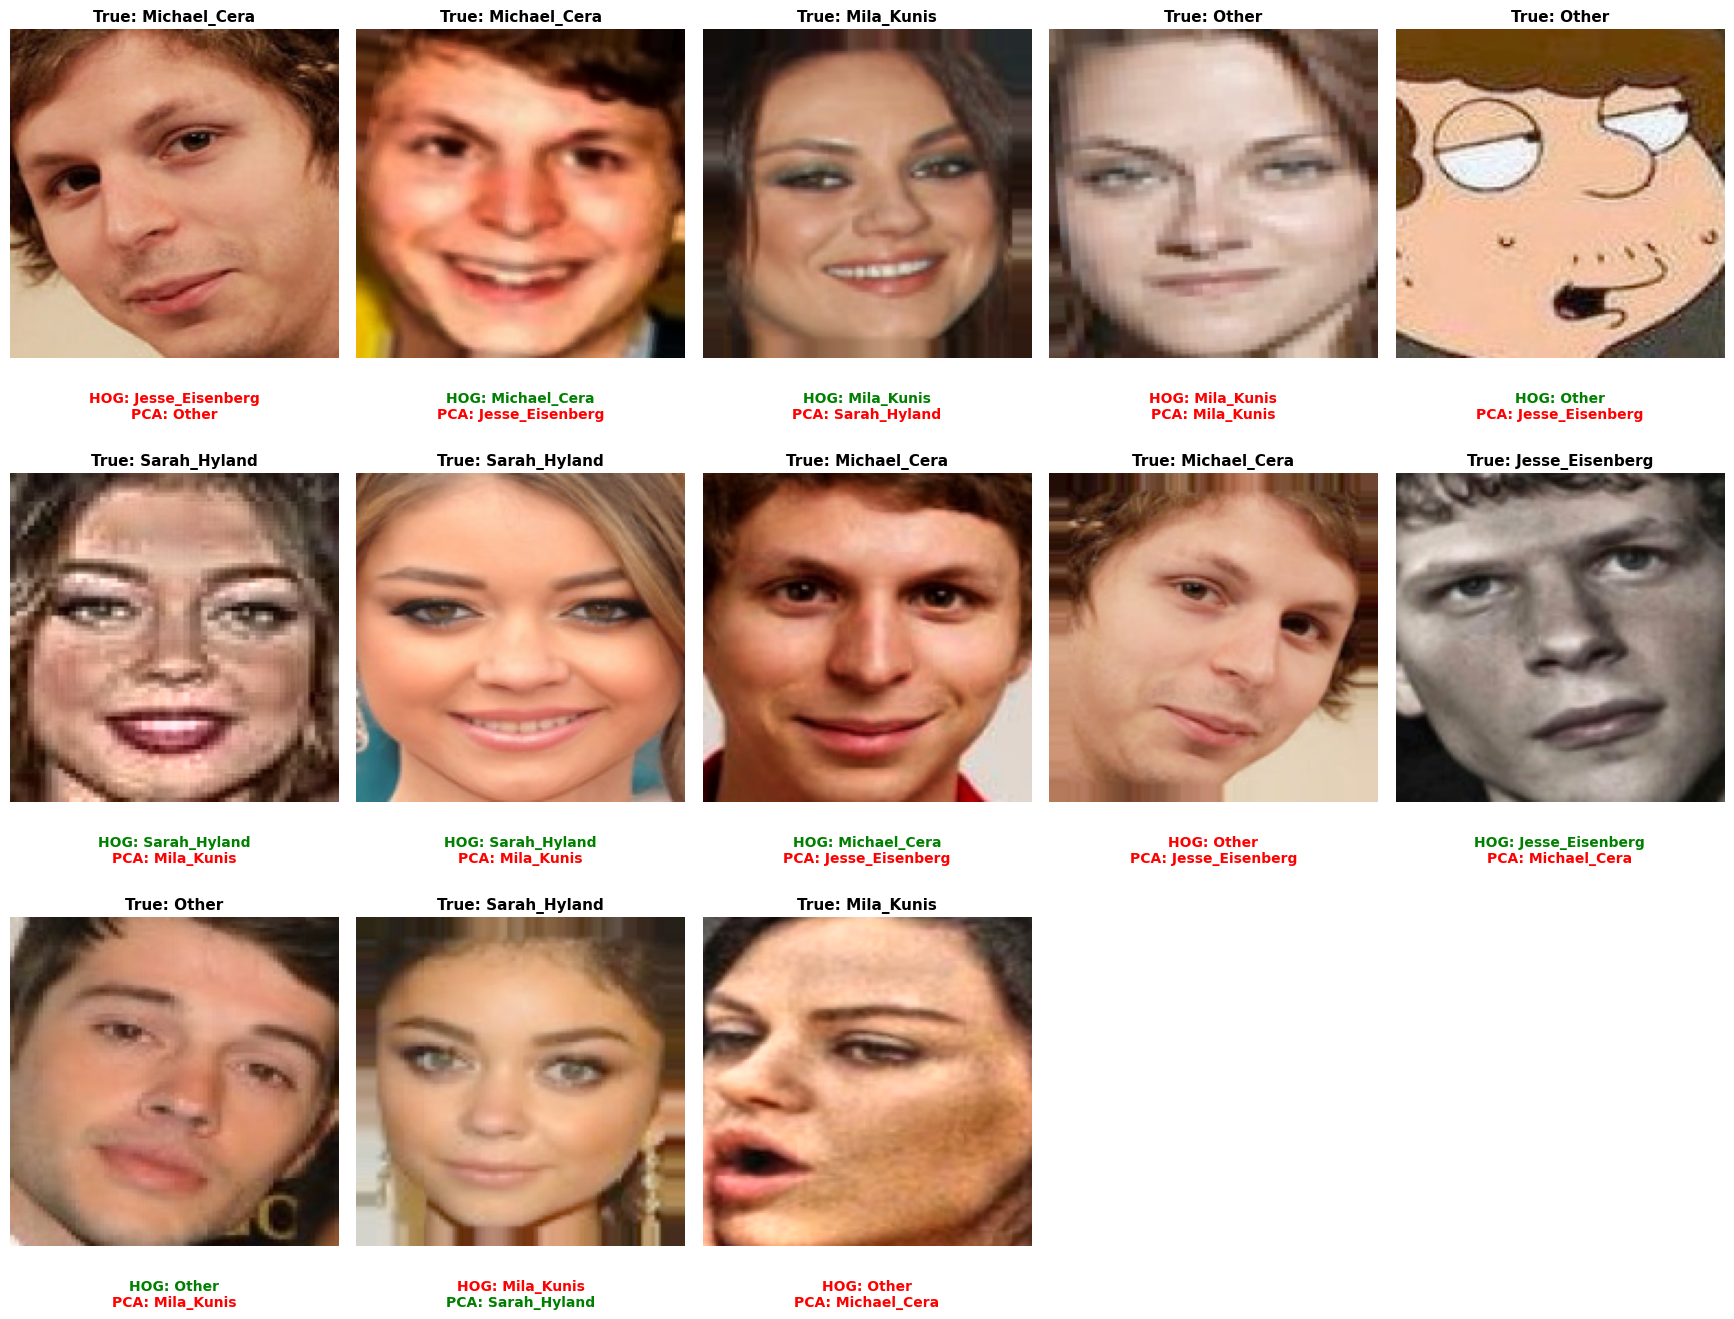

In [106]:

# ==========================================
# 5. Visualize Errors (Where HOG or PCA is wrong)
# ==========================================
# Find indices where either HOG OR PCA made an incorrect prediction
wrong_indices = np.where((y_val_pred_hog != y_val) | (y_val_pred_pca != y_val))[0]

print(f"\nFound {len(wrong_indices)} validation images where at least one model was wrong.")

if len(wrong_indices) > 0:
    # Set n_show to the total number of wrong images
    n_show = len(wrong_indices)
    indices_to_show = wrong_indices
    
    cols = 5
    # Dynamically calculate rows needed based on the total number of images
    rows = math.ceil(n_show / cols)
    
    # Scale the figure height based on the number of rows so images don't get squished
    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 4.5 * rows))
    
    # Flatten axes for easy iteration (handles both 1D and 2D arrays of axes)
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]
        
    for i, idx in enumerate(indices_to_show):
        ax = axes[i]
        img = X_val_img[idx]
        
        # Safely convert image for matplotlib display
        if img.dtype != np.uint8 and img.max() > 1.5:
            img_disp = np.clip(img / 255.0, 0, 1)
        else:
            img_disp = img
            
        ax.imshow(img_disp)
        ax.axis('off')
        
        # Get string labels
        true_label = CLASS_NAMES.get(y_val[idx], str(y_val[idx]))
        hog_pred = CLASS_NAMES.get(y_val_pred_hog[idx], str(y_val_pred_hog[idx]))
        pca_pred = CLASS_NAMES.get(y_val_pred_pca[idx], str(y_val_pred_pca[idx]))
        
        # Color code: Green if it matches ground truth, Red if it doesn't
        hog_color = "green" if y_val_pred_hog[idx] == y_val[idx] else "red"
        pca_color = "green" if y_val_pred_pca[idx] == y_val[idx] else "red"
        
        # Set True Label as the main title
        ax.set_title(f"True: {true_label}", color="black", fontsize=11, fontweight="bold")
        
        # Add HOG and PCA predictions directly below the image
        ax.text(0.5, -0.10, f"HOG: {hog_pred}", color=hog_color, 
                ha="center", va="top", transform=ax.transAxes, fontsize=10, fontweight="bold")
        ax.text(0.5, -0.15, f"PCA: {pca_pred}", color=pca_color, 
                ha="center", va="top", transform=ax.transAxes, fontsize=10, fontweight="bold")

    # Hide any unused subplots in the final row
    for j in range(n_show, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

## 4.3 Pre-Trained Neural Networks

To tackle the challenge of a small training dataset, we explore Deep Learning through Transfer Learning. Instead of training a network from scratch—which would quickly overfit our 80 images—we leverage models that have already learned to "see" by training on millions of images.

We test two different architectures:

* **MobileNetV2 (General Vision)**: A lightweight Convolutional Neural Network trained on ImageNet to recognize everyday objects. We freeze its core layers to act as a generic feature extractor and train only a new classification head on our specific subjects.

* **FaceNet (Specialized Vision)**: An Inception-ResNet architecture explicitly trained on the casia-webface dataset to understand facial biometrics. It directly maps face images into a highly discriminative 512-dimensional embedding space.

Instead of adding a new neural layer on top of FaceNet, we treat its output embeddings as our new feature set (replacing HOG or PCA) and feed them directly into a Support Vector Machine (SVM). This combination of deep, specialized feature extraction and robust statistical classification provides our most accurate predictions.

As we will see below, the neural networks provide a significant boost in accuracy.

### 4.3.1 General vision: MobileNetV2

In [107]:

# 1. Block TensorFlow's C++ logs and force CPU
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
warnings.filterwarnings('ignore')

# 2. Set the native MobileNetV2 resolution
NET_SIZE = 160 

# ==========================================
# 0. PRE-LOAD WEIGHTS (Run this once)
# ==========================================
print("Pre-loading MobileNetV2 weights...")
_ = MobileNetV2(weights='imagenet', include_top=False, input_shape=(NET_SIZE, NET_SIZE, 3))

# ==========================================
# 1. Preprocess with correct Resizing
# ==========================================
print(f"Resizing and Preprocessing for MobileNetV2 ({NET_SIZE}x{NET_SIZE})...")

# Resize images to the native network size
X_resized = np.array([cv2.resize(img, (NET_SIZE, NET_SIZE)) for img in X_train_final])

# Apply MobileNetV2 specific scaling (-1 to 1)
X_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(X_resized.astype(np.float32))

# ==========================================
# 2. Define Model Function
# ==========================================
def build_model(input_shape=(NET_SIZE, NET_SIZE, 3), num_classes=5):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False
    
    # Consolidated Keras layers
    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    x = tf.keras.layers.Dropout(0.3)(x)
    predictions = tf.keras.layers.Dense(num_classes, activation='softmax')(x) 
    
    model = tf.keras.Model(inputs=base_model.input, outputs=predictions)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ==========================================
# 3. Single Train/Validation Split
# ==========================================
print("\nSplitting data into 80% Train and 20% Validation...")
# stratify=y_train_final ensures both splits have a balanced mix of all classes
X_train, X_val, y_train, y_val = train_test_split(
    X_preprocessed, y_train_final, test_size=0.2, stratify=y_train_final, random_state=42
)

# ==========================================
# 4. Build and Train Model
# ==========================================
tf.keras.backend.clear_session() 
print("Building and training the model (this will only happen once)...")

model = build_model()

# Training the single model (verbose=1 lets you see the progress bar)
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1 
)

# ==========================================
# 5. Final Evaluation
# ==========================================
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
final_acc = accuracy_score(y_val, y_pred)

print("\n" + "="*45)
print("NEURAL NETWORK EVALUATION RESULTS")
print("="*45)
print(f"Final Validation Accuracy: {final_acc * 100:.2f}%")
print("="*45)

Pre-loading MobileNetV2 weights...
Resizing and Preprocessing for MobileNetV2 (160x160)...

Splitting data into 80% Train and 20% Validation...
Building and training the model (this will only happen once)...
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.3320 - loss: 1.8763 - val_accuracy: 0.5000 - val_loss: 1.2224
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5246 - loss: 1.2233 - val_accuracy: 0.6935 - val_loss: 0.8658
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6557 - loss: 0.8592 - val_accuracy: 0.7419 - val_loss: 0.7235
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7992 - loss: 0.6849 - val_accuracy: 0.7742 - val_loss: 0.6223
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8156 - loss: 0.5902 - val_accuracy: 0.8065 - val_loss: 0.5445
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8648 - loss: 0.4755 - val_accuracy: 0.8226 - val_loss: 0.4940
Epoch 7/20
16/16 ━━━━━━━━━━━━━

### 4.3.2 Specialised vision: FaceNet

Among the models we tested, FaceNet was the top performer. We therefore rely on FaceNet for our predictions using an RBF SVM. The model is trained on the 5 classes we created. However, for the final predictions, we convert these 5 classes back to the original 3: Mila = 2, Jesse = 1 and Other = 0.

In [108]:

# =============================================================================
# 0. Initialize Models (CPU Only for Reliability)
# =============================================================================
# Load the pre-trained FaceNet model
resnet = InceptionResnetV1(pretrained='casia-webface').eval()

# Explicitly force everything to the CPU to avoid CUDA/CUDNN memory crashes
device = torch.device('cpu')
resnet.to(device)

# =============================================================================
# 1. Feature Extraction (CPU)
# =============================================================================
def extract_facenet_features_cpu(faces_array, batch_size=32):
    """Simplified CPU-only extraction of FaceNet embeddings."""
    all_embeddings = []
    n_images = len(faces_array)
    
    for i in range(0, n_images, batch_size):
        batch_faces = faces_array[i : i + batch_size]
        processed_tensors = []
        
        for face_np in batch_faces:
            if face_np.max() <= 1.0:
                face_np = (face_np * 255).astype(np.uint8)
            else:
                face_np = face_np.astype(np.uint8)
                
            face_resized = cv2.resize(face_np, (160, 160))
            face_norm = (face_resized.astype(np.float32) - 127.5) / 128.0
            face_chw = np.transpose(face_norm, (2, 0, 1))
            
            processed_tensors.append(torch.tensor(face_chw.tolist(), dtype=torch.float32))
            
        batch_tensor = torch.stack(processed_tensors)
        
        with torch.no_grad():
            embeddings = resnet(batch_tensor)
            all_embeddings.append(embeddings.numpy()) 

    return np.vstack(all_embeddings)

# Extract Training Embeddings
print("Starting training on CPU...")
all_embeddings = extract_facenet_features_cpu(X_train_final, batch_size=32)
print(f"Success! Final training embeddings shape: {all_embeddings.shape}")

# =============================================================================
# 2. Train the SVM Classifier
# =============================================================================
clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=41)
clf.fit(all_embeddings, y_train_final)
print("SVM Classifier successfully trained!")

# =============================================================================
# 3. Prediction Pipeline
# =============================================================================
def predict_test_images(images, model, feature_extractor_func, face_detector, max_workers=4):
    """
    Parallelized face extraction and batch prediction.
    Priority logic: Mila (2) > Jesse (1) > Other (0).
    """
    all_face_crops = []
    face_to_img_idx = [] 
    
    def process_single_image(img_data):
        img_index, img = img_data
        local_crops = []
        
        if isinstance(img, str):
            img_arr = cv2.imread(img)
            if img_arr is None:
                return img_index, local_crops
        else:
            img_arr = img 
            
        faces = face_detector.detect_faces(img_arr)
        
        if faces:
            for (x, y, w, h, conf, sharp) in faces:
                face_crop = img_arr[y:y+h, x:x+w]
                local_crops.append(face_crop)
                
        return img_index, local_crops

    # Extract faces in parallel
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = executor.map(process_single_image, enumerate(images))
        for img_idx, crops in results:
            for crop in crops:
                all_face_crops.append(crop)
                face_to_img_idx.append(img_idx)
                
    # Fallback if absolutely no faces are found in the batch
    if not all_face_crops:
        return [0] * len(images)
        
    # Batch Feature Extraction & Prediction
    embeddings = feature_extractor_func(all_face_crops)
    predictions = model.predict(embeddings)
    
    # Priority Logic Mapping
    final_results = [0] * len(images)
    preds_per_image = {}
    
    for img_idx, pred in zip(face_to_img_idx, predictions):
        if img_idx not in preds_per_image:
            preds_per_image[img_idx] = []
        preds_per_image[img_idx].append(pred)
        
    for i in range(len(images)):
        if i in preds_per_image:
            img_preds = preds_per_image[i]
            if 2 in img_preds:      
                final_results[i] = 2 # Mila
            elif 1 in img_preds:    
                final_results[i] = 1 # Jesse
            else:
                final_results[i] = 0 # Other
                
    return final_results
    
# =============================================================================
# 4. Run Inference on Test Set
# =============================================================================
# Ensure detector is initialized (Requires DNNFaceDetector to be in memory)
face_detector = DNNFaceDetector(path="models", face_size=TARGET_SIZE)

all_raw_images = test['img'].tolist()
final_test_predictions = []
batch_size = 32 

for i in tqdm(range(0, len(all_raw_images), batch_size), desc="Classifying Test Batches"):
    batch_images = all_raw_images[i:i + batch_size]
    
    batch_labels = predict_test_images(
        images=batch_images, 
        model=clf, 
        feature_extractor_func=extract_facenet_features_cpu, # <-- FIX: Pointing to the CPU function
        face_detector=face_detector
    )
    
    final_test_predictions.extend(batch_labels)

# Save to dataframe
test['predictions'] = final_test_predictions

print("\nDone! Ready to generate submission.csv.")

Starting training on CPU...
Success! Final training embeddings shape: (306, 512)
SVM Classifier successfully trained!


Classifying Test Batches: 100%|██████████| 57/57 [00:40<00:00,  1.42it/s]


Done! Ready to generate submission.csv.


Before submitting, we inspect visually 100 predictions. We observe that the predictions are very accurate: almost all images are correctly classified. Our uploads to Kaggle confirm this observation: Our FaceNet implementation achieves >95% accuracy on the test set.

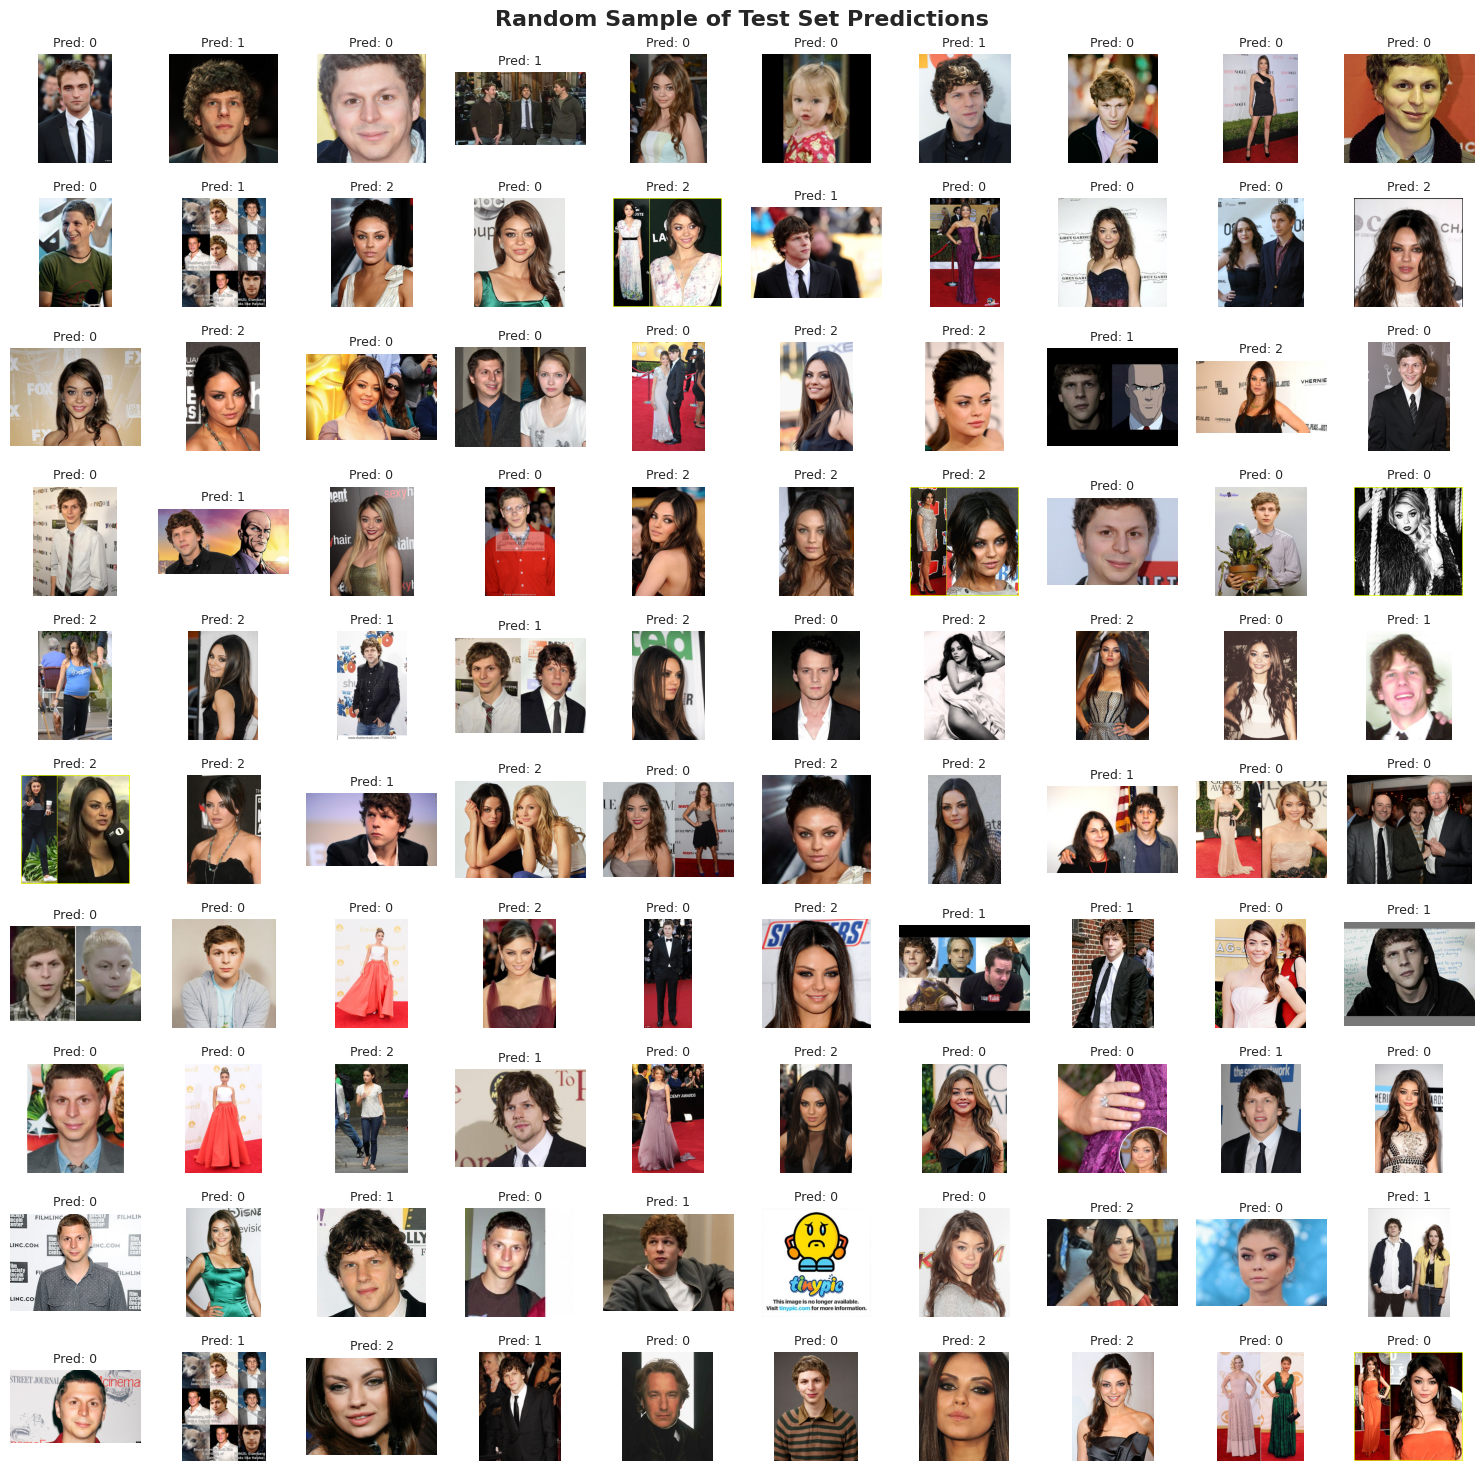

In [109]:

# 1. Load the labels back from your saved file or memory
if 'final_test_predictions' in globals() and final_test_predictions:
    labels = np.array(final_test_predictions)
else:
    submission_df = pd.read_csv('submission.csv')
    labels = submission_df['class'].values

# 2. Setup the plotting grid (10x10)
fig, axes = plt.subplots(10, 10, figsize=(15, 15)) # Adjusted size to be a bit more compact
axes = axes.flatten()

# 3. Safely get exactly 100 unique random indices
# (Failsafes to the length of the test set if there are fewer than 100 images)
n_samples = min(100, len(test))
random_indices = np.random.choice(len(test), n_samples, replace=False)

for i, rnd in enumerate(random_indices):
    # --- THE BULLETPROOF IMAGE FIX ---
    # Copy the image to avoid modifying your original dataframe
    img = test.iloc[rnd]['img'].copy()
    
    # Force to float32 for safety
    if img.dtype != np.float32:
        img = img.astype(np.float32)
        
    # If the pixels are on a 0-255 scale, scale them down to 0.0 - 1.0
    if img.max() > 2.0: 
        img = img / 255.0
        
    # Clip strictly to 0.0 - 1.0
    img_display = np.clip(img, 0, 1)
    # ---------------------------------
    
    # Display the image
    axes[i].imshow(img_display)
    
    # Set the title using the predicted class
    # (Optional: You can map this back to names using CLASS_NAMES if you want!)
    axes[i].set_title(f"Pred: {labels[rnd]}", fontsize=9)
    axes[i].axis('off')

# Hide any remaining axes if test set had fewer than 100 images
for j in range(n_samples, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
fig.suptitle("Random Sample of Test Set Predictions", fontsize=16, fontweight='bold')
plt.show()

# 5. Submitting best results

In [110]:
submission = test.copy().drop('img', axis=1)
submission = submission.drop('predictions', axis=1)
submission['class'] = final_test_predictions
submission.to_csv('submission.csv')

print(f"Saved {len(submission)} predictions to submission.csv")
submission.head()

Saved 1816 predictions to submission.csv


,class
id,
0,1
1,0
2,0
3,0
4,1


# 6. Discussion

## 6.1 Improving Performance: Our 'zero-to-hero' journey

### Phase 1: Full images and basic detection
We began by running **HOG (Histogram of Oriented Gradients)** and **PCA (Principal Component Analysis)** on the original, uncropped images (this appraoch was faster as we started working in parallel on improving face detection, HOG and PCA). The models performed better than a random guess, but they were easily distracted by backgrounds, clothing, and hair. The obvious next step was feeding the cropped faces to HOG and PCA.

### Phase 2: Improving face detection (HAAR vs. DNN)
We tested two ways to find faces in a picture:
* **HAAR Cascades:** This is an older, faster method. It looks for simple patterns of light and dark (like the bridge of the nose being brighter than the eye sockets). However, it often missed faces at odd angles.
* **DNN (Deep Neural Network):** We switched to a modern DNN approach because it is much more accurate. It can find faces even in poor lighting or when the person isn't looking directly at the camera.

### Phase 3: Fine-tuning and data augmentation
Once we were feeding cropped faces into our models, performance jumped. We tested multiple configurations for HOG and PCA using simple classifier (initially LinearSVM). Once we selected the best configurations, we benchmarked classifiers to identify the top classifiers. Then we retested our HOG and PCA configurations to verify the results didn't change.

### Phase 4: Fine-tuning and data augmentation
To help the models learn better, we "augmented" our small dataset:
* **Extracting multiple faces:** If a photo had three people, we saved all three faces as separate training examples.
* **Creating variants:** We made copies of our images and slightly changed them — rotating them, flipping them sideways, or changing the brightness. This teaches the model that Jesse is still Jesse, even if the photo is a bit tilted or dark.

### Phase 4: Moving to deep learning
With HOG and PCA hitting a "ceiling" (~80% and ~70% accuracy respectively), we moved to Neural Networks. Because we only had 80 original images, we used **Transfer Learning**. This means taking a massive "pre-trained" model that already knows how to recognize shapes and just teaching it the final step: identifying our specific people. We initially tested MobileNetV2 which is a very fast object detector. It is trained to recognise many different objects. The result was a immediate 10 percentage point increase in accuracy compared to HOG (~90% accuracy).

### Phase 5: The final refinement (5 classes and FaceNet)
Our final implementation had three major changes:
*  **Account for multiple faces in the test set**: Up until now, our algorithm was identifying only 1 face per image and classifying it accordingly. The predictions were the dependent on which face was detected. This was our fix: when there are multiple faces in an image, we should check all faces for the presence of Jesse (1) or Mila (2), before allocating to the 'Other' class (0)
*  **From 3 classes to 5:** Originally, Michael and Sarah were lumped into a "Neither" class. This is likely to confuse the model because they look very different from each other. In addition, there are also images in the test set where neither Mila, Jesse, Michael or Sarah are present. The model would then need to allocate a stranger's face (or even not a real person) to one of the 3 classes which does not make sense. By giving Michael, Sarah and 'Other' their own classes, the model can better learn the difference between Michael vs. Jesse and Mila vs. Sarah, and recognise when neither of the four are in an image.
*  **FaceNet:** We swapped the general-purpose MobileNetV2 for **FaceNet**. While MobileNet is a generalist (trained on dogs, cars, and trees), FaceNet is a specialist trained specifically on millions of faces. This led to our highest accuracy yet.

Our FaceNet implementation performs very well, achieving >95% accuracy on the test set.

## 6.2 What we learned
We learned that **data quality is important** for accurate classification and that it is critical to review carefully the data before training. We spent a significant amount of time preparing the training data. We also learned how to implement the "small data" problem using augmentation and transfer learning.

Our overall observations on HOG vs. PCA:
* **HOG (Local Structure):** HOG focuses on local shapes and edges (like the curve of a chin or the outline of an eye). It works best when faces are aligned and you want to capture the geometry of a person's features.

* **PCA (Global Patterns):** PCA looks at the "big picture"—it tries to represent the whole face as a combination of basic patterns (Eigenfaces). It is very sensitive to lighting and head position. If the lighting changes drastically, PCA often fails because the "global" brightness changes, even if the person’s features stay the same.

Overall, HOG was outperforming PCA, so we do see the benefits or creating handcrafted features. However, as expected, our neural networks implementations were able to significantly outperform HOG.

Our performance is still limited by the **data imbalance** in the training data. We have many photos of Jesse and Mila, but very few photos of "Other" people. This makes the model slightly biased — we think it expects to see one of our four main celebrities and might struggle to realize when it is looking at a complete stranger.

If we had more time, we could:
*  **Hyper-parameter tuning on the neural networks:** We would run much longer tests to find the further improve the performance of our neural networks.

*  **3D Alignment:** Implement a step to "straighten" faces (rotate them so the eyes are always level) before processing them, to see if it improves the performance of HOG and PCA.

More generally, it would also be useful to make the training data more balanced, notably by adding more pictures of random people which are very rare in the training data.
